## 1. Variables aleatorias discretas


In [2]:
import numpy as np
import numpy.random as npr # para generar numeros aleeatorios
import matplotlib.pyplot as plt
import scipy.stats as sps # distribuciones

from scipy.stats import bernoulli # importar cada distribución

Para más información de las distribuciones discretas y continuas, [VER](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Variable aleatoria uniforme discreta

Una variable aleatoria $X$ tiene distribución uniforme discreta en el conjunto $\{x_{1},\dots,x_{n}\}$ si su función de masa de probabilidades está dada por
$$f_{X}(k)=\mathbb{P}(X=k)=\begin{cases}
\frac{1}{n} &\quad \text{si } k\in\{x_{1},\dots,x_{n}\} \\
0 &\quad \text{en otro caso}
\end{cases}$$

**Notación:** $X\sim Unif(x_{1},\dots,x_{n}).$

Se llama uniforme porque cada uno de los posibles valores de $X$ tienen la misma probabilidad.

Si $X\sim Unif(x_{1},\dots,x_{n})$, en este caso, se tiene:
	$$\mathbb{E}[X] = \sum_{k}kf_{X}(k)=\frac{x_n + x_1}{2}.$$
	y
	$$\text{Var}(X) = \mathbb{E}[(X-\mathbb{E}[X])^{2}] =\sum_{k}(k-\mathbb{E}[X])^{2}f_{X}(k)=\frac{(x_n - x_1+1)^2-1}{12}$$

$\color{red}{\text{Ejercicio 1.}}$ Verifica que, en efecto, la esperanza y varianza de una variable uniforme está dada como antes.

**Ejemplo** Se lleva a cabo una rifa donde los boletos están enumerados del $00$ al $99$. Si $Y$ es la variable aleatoria definida como el número del boleto ganador, entonces:  
$$\mathbb{P}(Y=k)=\begin{cases}
	\frac{1}{100} &\quad \text{si } k=00,01,\dots,99 \\
	0 &\quad \text{en otro caso}
\end{cases}$$
Consideremos que el premio de la rifa se determina a partir del número premiado de la siguiente forma: $X=Y+1$, donde $X$ es el monto del premio en pesos y $Y$ es el número premiado, entonces $X$ es una variable aleatoria, pues es una función de $Y$, y además se tiene
	$$f_{X}(k)=\begin{cases}
		\frac{1}{100} &\quad \text{si } x=1,2,\dots,100 \\
		0 &\quad \text{en otro caso}
	\end{cases}$$
Entonces, la esperanza y varianza de $X$ están dados por:
	$$\mathbb{E}[X] = \sum_{k=1}^{100}k\left(\frac{1}{100}\right) = \frac{1}{100}\sum_{k=1}^{100}k = \frac{1}{100}\left[\frac{100(100+1)}{2}\right] = 50.5$$
	y
	$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \sum_{k=1}^{100}k^{2}\left(\frac{1}{100}\right)-(50.5)^{2} = 833.25$$   


    
Supongamos que nos interesa calcular la probabilidad de que el premio sea mayor a $\$80$, entonces
	$$\mathbb{P}(X>80) = \sum_{k=81}^{100}\frac{1}{100} = \frac{20}{100} = 0.2$$
	Su función de distribución esta dada por:
	$$F_{X}(x)=\mathbb{P}(X\le x)=\begin{cases}
		0 &\quad \text{si } x<1 \\
		\frac{x}{100} &\quad \text{si } x=1,2,\dots,100\\ 1 &\quad \text{si } x>100
	\end{cases}$$     

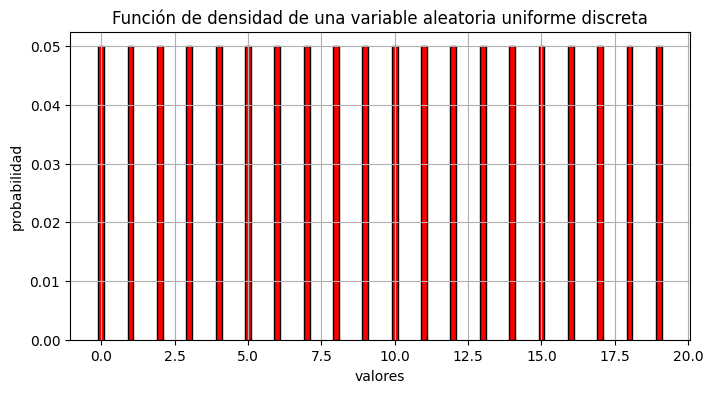

In [3]:
# Distribución uniforme discreta
min = 0
max = 20
x = np.arange(min, max)

# Vamos a crear la función de densidad (pmf (probability mass function))
pmf_unif = np.full_like(x, 1/(max-min), dtype=float) # crear un arreglo del mismo tamaño

#Graficamos la función de densidad
plt.figure(figsize=(8,4))
plt.bar(x, pmf_unif, width=0.2, color='r', edgecolor='black') # grafica de barras
plt.xlabel("valores")
plt.ylabel("probabilidad")
plt.title("Función de densidad de una variable aleatoria uniforme discreta")
plt.grid(True)
plt.show()

Para más información sobre los colores en Matplotlib, ver [ColoresMatplotlib](https://matplotlib.org/stable/gallery/color/named_colors.html)

## Variable aleatoria Bernoulli con parámetro $p\in (0,1)$.

El modelo probabilístico Bernoulli se aplica a un experimento cuyo espacio muestral está constituido sólo por dos resultados posibles, éxito y fracaso:

Se considerará una v.a $X$ sobre el espacio muestral $$\Omega=\{\text{éxito, fracaso}\}$$
de tal forma que
* $X(\{\text{éxito}\}) = 1$
* $X(\{\text{fracaso}\}) = 0$

Las probabilidades asociadas a este modelo son:

* $\mathbb{P}(\{\text{éxito}\}) = p$
* $\mathbb{P}(\{\text{fracaso}\}) = 1-p$

donde $0<p<1$.
### Función de masa de probabilidad (pmf)

Entonces la función de densidad de masa de probabilidades de $X$ está dada por:

$$f_{X}(k)=\begin{cases}
p &\quad \text{si } k=1 \\
1-p &\quad \text{si } k=0
\end{cases}$$

**Notación:** $X\sim \text{Ber}(p)$.

### Función de distribución (CDF)

$$F_{X}(x)=\begin{cases}
0 &\quad \text{si } x<0 \\
1-p &\quad \text{si } 0\leq x < 1 \\
1 &\quad \text{si } x  \geq 1
\end{cases}$$


Esta variable aleatoria es muy importante. En la practica es usada para modelar situaciones en las cuales hay dos posibles resultados como:
* el estado de un teléfono en un momento dado: libre u ocupado.
* una persona pueda estar enferma o sana de una determinada enfermedad.
* la preferencia de una persona, la cual puede estar a favor o en contra de un candidato determinado.

Mediante la combinación de variables aleatorias Bernoulli es posible construir otras variables aleatorias.

### Esperanza y Varianza

Si $X\sim \text{Ber}(p)$, entonces su esperanza es:
\begin{align*}
\mathbb{E}[X] = \sum_{k=0}^{1}kf_{X}(k) = 1\cdot p + 0\cdot (1-p) = p.
\end{align*}

Y su varianza se calcula usando,
$$\mathbb{E}[X^{2}] = \sum_{k=0}^{1}k^{2}f_{X}(k) = 1^{2}\cdot p + 0^{2}\cdot (1-p) = p.$$
Por lo tanto,
$$\text{Var}(X)=\mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = p-p^{2} = p(1-p)$$

### Función generadora de momentos (mgf)

$$\mathbb{M}_{x}(t)= \mathbb{E}[e^{tX}] = (1-p)+pe^{t}$$

### Función característica

$$\varphi_{X}(\omega) = \mathbb{E}[e^{i\omega X}] = (1-p)+pe^{i\omega}$$

La función de densidad es: [0.2 0.8]


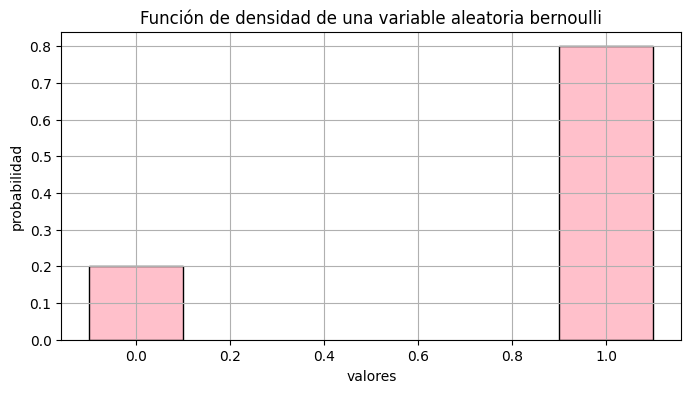

In [4]:
# Grafica de la distribución Bernoulli
# Definir mi probabilidad de éxito
p= 0.8 # éxito

# Defino los posibles valores de la variable aleatoria
x = [0,1]

# Calcular la función de masa de probabilidad
pmf_ber = bernoulli.pmf(x,p)

print("La función de densidad es:", pmf_ber)

# Graficamos la función de densidad
plt.figure(figsize=(8,4))
plt.bar(x, pmf_ber, width = 0.2, color = "pink", edgecolor = "k")
plt.xlabel("valores")
plt.ylabel("probabilidad")
plt.title("Función de densidad de una variable aleatoria bernoulli")
plt.grid(True)
plt.show()

In [5]:
media = bernoulli.mean(p)
varianza = bernoulli.var(p)
print("La esperanza es:", media)
print("La varianza es:", varianza)

La esperanza es: 0.8
La varianza es: 0.15999999999999992


## Variable aleatoria Binomial con parámetros $n$ y $p\in (0,1)$.

X ~ Binomial(n, p) cuenta el número de “éxitos” en n ensayos de Bernoulli independientes, cada uno con probabilidad de éxito p.

Ejemplos: número de compras entre n clientes (p = probabilidad de comprar), número de piezas buenas en un lote de n (p = probabilidad de “buena”).

### Función de masa de probabilidad (pmf)

Decimos que una v.a $X$ tiene distribución binomial con párametros $n$ y $p$, si su función de densidad de masa de probabilidades está dada por:
$$\begin{equation*}
	f_{X}(k)=\begin{cases}
	\binom{n}{k}p^{k}(1-p)^{n-k} &\quad \text{si } k=0,1,\dots,n \\
	\qquad 0 &\quad \text{en otro caso}  
	\end{cases}
\end{equation*}$$
donde $n$ es un entero positivo y $0< p< 1$.

### Función de distribución (CDF)

$$\begin{equation*}
	F_{X}(k)=\begin{cases}
	0 &\quad \text{si } k < 0 \\
	\sum^{|x|}_{k= 0}\binom{n}{k}p^{k}(1-p)^{n-k} &\quad 0 \leq k < n \\
	1 &\quad k \geq n
	\end{cases}
\end{equation*}$$

### Esperanza y Varianza
La esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum_{k \mathop = 0}^n k \binom n k p^k (1-p)^{n - k}\\
&=\sum_{k \mathop = 1}^n k \binom n k p^k (1-p)^{n - k}\\
&= \sum_{k \mathop = 1}^n n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum_{k \mathop = 1}^n \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{( {n - 1}) - ( {k - 1}) }\\
&=n p \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\\
&=np
\end{align*}

Ahora,
\begin{align*}
\mathbb{E}[X^2]&= \sum_{k \mathop = 0}^n k^2 \binom n k p^k (1-p)^{n - k}\\
&=\sum_{k \mathop = 0}^n k n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum_{k \mathop = 1}^n k \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{({n - 1}) - ({k - 1}) }\\
&= n p \sum_{j \mathop = 0}^m ({j + 1}) \binom m j p^j (1-p)^{m - j}\\
&=n p \left( {\sum_{j \mathop = 0}^m j \binom m j p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&=n p \left( {\sum_{j \mathop = 0}^m m \binom {m - 1} {j - 1} p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&= n p \left( (n - 1) p \sum_{j \mathop = 1}^m \binom {m - 1}{j - 1} p^{j - 1} (1-p)^{( {m - 1}) - ({j - 1}) } + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\right) \\
&= n p \left( (n - 1) p (p + (1-p))^{m - 1} + (p + (1-p))^m\right)\\
&= n p ((n - 1) p + 1)\\
&= (np)^2 +np(1-p),
\end{align*}

por lo que la varianza de $X$ es:
$$\text{Var}(X)=np(1-p).$$

**Ejemplo** Una moneda no justa se tira 6 veces, donde la probabilidad de obtener sol es de $0.3$.

Sea $X$ el número de veces que cae sol, entonces $X$ tiene una distribución binomial con parámetros $n=6$ y $p=0.3$. Por lo que
$$\begin{align*}
\mathbb{P}(X=2) &= \binom{6}{2}(0.3)^{2}(0.7)^{4}=0.3241 \\
\mathbb{P}(X=3) &= \binom{6}{3}(0.3)^{3}(0.7)^{3}=0.1852 \\
\mathbb{P}(1<X\le 5) &= \mathbb{P}(X=2)+\mathbb{P}(X=3)+\mathbb{P}(X=4)+\mathbb{P}(X=5) \\
			&= 0.3241 + 0.1852 + \binom{6}{4}(0.3)^{4}(0.7)^{2} + \binom{6}{5}(0.3)^{5}(0.7)^{1} \\
			&= 0.5093 + 0.0595 + 0.0102 = 0.579
\end{align*}$$

Note que la probabilidad $$\mathbb{P}(1<X\leq 5)=F_{X}(5)-F_{X}(1).$$

Usando el tributo `.cdf `, podemos calcualr la probabilidad anterior:

In [6]:
from scipy.stats import binom
# Proba de que haya 5 o menos éxitos en 6 ensayos
F5 = binom.cdf(5,6,0.3) # x=5, n=6, p=0.3

# Proba de que haya 1 o menos éxitos en 6 ensayos
F1 = binom.cdf(1,6,0.3) # x=5, n=6, p=0.3

In [7]:
F5-F1

np.float64(0.5790960000000003)

### Vamos a grafiar la función de densidad de una binomial

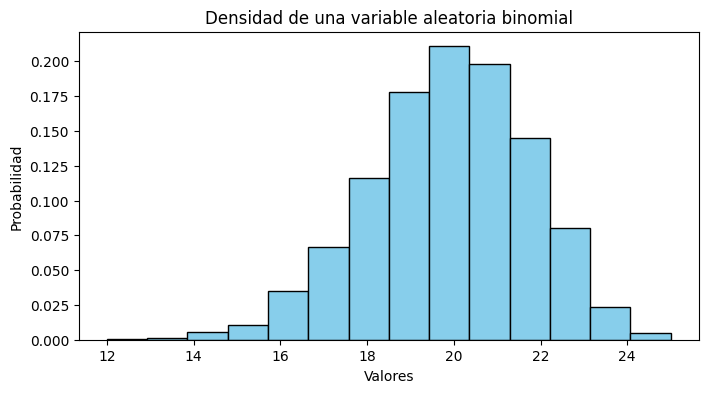

In [8]:
# Grafica de la distribución Binomial

# Parámetros
n = 25
p = 0.8

# Generamos numeros aleatorios con distribución binomial
binom_numeros = sps.binom.rvs(n,p,size = 10000)

# Creamos un histograma
plt.figure(figsize=(8,4))
plt.hist(
    binom_numeros,
    density = True, # normaliza para que sea función de densidad
    bins = len(np.unique(binom_numeros)), # numero de barras en el histograma
    color = "skyblue",
    edgecolor = 'k'
)

plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Densidad de una variable aleatoria binomial')
plt.show()

## Variable aleatoria Poisson

Es una distribución de probabilidad discreta que  sirve para calcular la probabilidad de que ocurra un determinado **número de eventos raros** durante un intervalo dado (puede ser de tiempo, longitud, área, etc.

Esta variable aleatoria toma los valores sobre el conjunto $\{0,1,2,\dots\}$ y tiene un parámetro $\lambda>0$, el cual representa el número de veces que se **espera** que ocurra un evento durante un intervalo dado.

Modela el número de eventos que ocurren en un intervalo (de tiempo, espacio, etc.) cuando:
Los eventos ocurren de manera independiente.
La tasa media es constante ($\lambda$ eventos por unidad de medida).
En intervalos muy pequeños, la probabilidad de ≥2 eventos es despreciable.

Ejemplos: número de llamadas que llegan a un call center por minuto; defectos en 1 m² de tela; clics por minuto en un sitio.

### Función de masa de probabilidad (pmf)
La función de masa de probabilidades de una variable aleatoria Poisson, $X$, está dada por:
$$f_{X}(k)=\begin{cases}
	e^{-\lambda}\frac{\lambda^{k}}{k!} &\quad \text{si } k=0,1,2,\dots \lambda > 0\\
	0 &\quad \text{en otro caso}  
\end{cases}$$


En efecto, es una función de masa de probabilidades debido a que
$$\begin{align*}
\sum_{k=0}^{\infty}e^{-\lambda}\frac{\lambda^{k}}{k!} &= e^{-\lambda}\sum_{k=0}^{\infty}\frac{\lambda^{k}}{k!} \\ &= e^{-\lambda}\underbrace{\left(1+\lambda+\frac{\lambda^{2}}{2!}+\frac{\lambda^{3}}{3!}+\cdots\right)}_{\text{desarrollo de Taylor de }e^{\lambda}} \\ &= e^{-\lambda}e^{\lambda}=1.
\end{align*}$$

### Función de distribución (CDF)

$$F_{X}(k)=\begin{cases}
	0 &\quad x < 0\\
	\sum_{i=0}^{|k|}e^{-\lambda}\frac{\lambda^{i}}{i!} &\quad x \geq 0
\end{cases}$$

### Esperanza y varianza
Se tiene que $\mathbb{E}[X] = \lambda$ y $\text{Var}(X)= \lambda$.

### Función generadora de momentos (mgf)

$$M_{x}(t) = exp(\lambda(e^{t}-1))$$

### Función característica

$$\varphi_{x}(\omega) = exp(\lambda(e^{i\omega}-1))$$



**Aplicaciones**

**Ejemplo:** Supongamos que el número de accidentes que ocurre en un punto tiene una distribución Poisson con parámetro $\lambda=2$.
* ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes?
  $$
  \begin{align*}
	\mathbb{P}(X>2) &= 1-\mathbb{P}(X\le 2) \\ &=1-\left[\mathbb{P}(X=0)+\mathbb{P}(X=1)+\mathbb{P}(X=2)\right] \\ &= 1-\left[\frac{e^{-2}2^{0}}{0!}+\frac{e^{-2}2^{1}}{1!}+\frac{e^{-2}2^{2}}{2!}\right] \\ &= 1-e^{-2}\left[1+2+2\right] = 1-5e^{-2} = 0.3233
  \end{align*}
  $$

* ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes, sabiendo que ocurre por lo menos uno?
$$\begin{align*}
\mathbb{P}(X>2 \mid X\ge 1) = \frac{\mathbb{P}(X>2 \cap X\ge 1)}{\mathbb{P}(X\ge 1)} = \frac{\mathbb{P}(X>2)}{\mathbb{P}(X\ge 1)} = \frac{1-\mathbb{P}(X\leq 2)}{1-\mathbb{P}(X<1)} = \frac{1-5e^{-2}}{1-e^{-2}} = \frac{0.3233}{0.8646} = 0.3739
\end{align*}$$
ya que $\mathbb{P}(X\ge 1)=1-\mathbb{P}(X<1)=1-\mathbb{P}(X=0)=1-e^{-2}$

Para ver más información, revisar [Poisson](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html)

Ahora, vamos a calcular las probabilidades anteriores usando el atributo `.cdf`

In [9]:
from scipy.stats import poisson

In [10]:
# Sea el parametro lambda = 2
lamb = 2

# Probabilidad de más de dos accidentes
prob_mas2 = 1 - poisson.cdf(2,lamb)

print("P(X>2) =",prob_mas2)
print("La probabilida de que ocurran más de dos accidenrtes es: ",prob_mas2)

# Proba condicional
p_mas2_dado_uno = prob_mas2 / (1 - poisson.cdf(0,lamb))
p_mas2_dado_uno

print("P(X>2 | X >= 1) =",p_mas2_dado_uno)

P(X>2) = 0.3233235838169366
La probabilida de que ocurran más de dos accidenrtes es:  0.3233235838169366
P(X>2 | X >= 1) = 0.37392942900133747


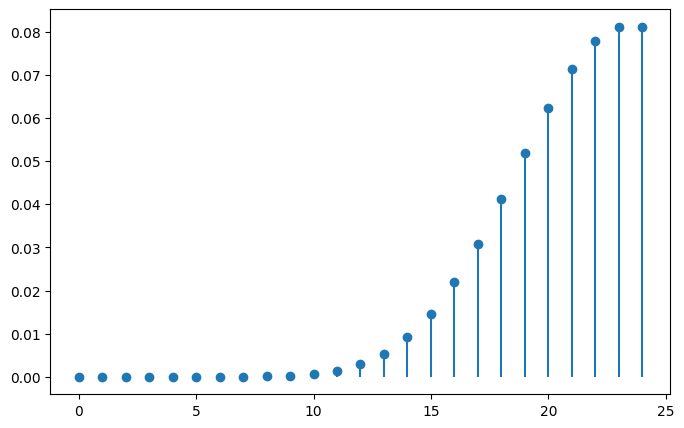

In [11]:
# Grafica de la densidad Poisson

x = np.arange(0,25)
y = poisson.pmf(x,24)

plt.figure(figsize=(8,5))
plt.vlines(x,0,y) #lineas verticales
plt.plot(x,y,'o')
plt.show()


## Aproximación de Poisson a la Binomial
La distribución de Poisson es una forma límite de la distribución binomial, es decir, es una buena aproximación cuando $n$ es suficientemente grande y $p$ suficientemente pequeña.

$\textbf{Teorema (Poisson).-}$ Sean $S_{n}\sim Bin(n,p_{n})$ bajo el regimen $$\lim_{n\to \infty}np_{n}=\lambda>0.$$
Consideremos la siguiente sucesión de números reales:
$$a_{j}(n,p_n)=\begin{cases}\binom{n}{j}(p_n)^{j}(1-p_{n})^{n-j} & j\leq n\\
0 & j\geq n+1\end{cases}$$

 Entonces,
 $$\lim_{n\to \infty}a_{j}(n,p_n)=a_{j}=e^{-\lambda}\frac{\lambda^{j}}{j!} \ \ \forall j\in \mathbb{N}.$$

 El teorema anterior implica que la distribución de Poisson ofrece un modelo probabilístico adecuado para todos aquellos experimentos aleatorios 	en los que las repeticiones son independientes unas de otras y en los 	que sólo hay dos posibles resultados: éxito o fracaso, con probabilidad de 	éxito pequeña, y en los que el interés se centra en conocer el número de éxitos obtenidos al realizar el experimento un número suficientemente grande de veces.

Empíricamente se ha establecido, que la aproximación se puede aplicar con seguridad si $n\ge100$, $p\le 0.01$ y $np \le20$.

**Ejemplo** Supongamos que la probabilidad de que un producto producido por cierta máquina es defectuoso es de $0.1$. ¿Cuál es la probabilidad de que un lote de 10 productos contenga a lo más un producto defectuoso?

Sea $X$ el número de productos defectuosos, y sabemos que $X$ tiene una distribución binomial con parámetros $n=10$ y $p=0.1$, entonces
\begin{align*}
\mathbb{P}(X\le 1) &= \mathbb{P}(X=0)+\mathbb{P}(X=1) \\ &= \binom{10}{0}(0.1)^{0}(0.9)^{10-0}+\binom{10}{1}(0.1)^{1}(0.9)^{10-1} \\ &= 0.7361
	\end{align*}

Ahora, con la distribución Poisson, tenemos que $\lambda=10(0.1)=1$, por lo que
$$\mathbb{P}(X\le 1) = \mathbb{P}(X=0)+\mathbb{P}(X=1) = \frac{e^{-1}1^{0}}{0!}+\frac{e^{-1}1^{1}}{1!} = e^{-1}+e^{-1} =0.7358$$

## Variable aleatoria Geométrica con parámetro $p\in (0,1)$.

Esta variable aleatoria cuenta el número de fracasos antes del primer éxito en ensayos bernoulli independientes con parámetro $0<p<1$

### Función de masa de probabilidad (pmf)

su función de masa de probabilidades está dada por:
$$f_{X}(k)=\begin{cases}
	p(1-p)^{k-1} &\quad \text{si } k=1,2,\dots \\
	\qquad 0 &\quad \text{en otro caso}  
\end{cases}$$


Notación. $X\sim Geo(p)$

La cual es una función de densidad ya que:
* $0\le f_{X}(k)\le 1$ para toda $x$.
* $$\begin{align*}
	\sum_{k\in R_{X}}f_{X}(k) &= \sum_{k=1}^{\infty}(1-p)^{k-1}p \\
			&= p\sum_{y=0}^{\infty}(1-p)^{y} \\
			&= p\left(\frac{1}{1-(1-p)}\right) = 1
		\end{align*}$$

Si por el contrario queremos contar el número de éxitos antes del primer fracaso, tenemos que la función de está dada por:
	$$f_{X}(k)=\begin{cases}
		p^{k}(1-p) &\quad \text{si } k=0,1,2,\dots \\
		\qquad 0 &\quad \text{en otro caso}  
	\end{cases}$$

Para calcular la Esperanza y Varianza de $X$, necesitamos del siguiente lema:

**Lema 1** Sea $x$ un número real tal que $│x│<1$. Entonces,
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}.$$
**Demostración.** Se tiene que
$$\frac{d}{dx}\sum_{k=1}^{\infty}x^{k}=\sum_{k=1}^{\infty}kx^{k-1}.$$
Además,
$$\sum_{k=1}^{\infty}x^{k}=\frac{x}{1-x}.$$
Por lo tanto,
$$\frac{d}{dx}\frac{x}{1-x}=\frac{1}{(1-x)^2}.$$

Como corolario,
$$\sum_{k=1}^{\infty}k(k+1)x^{k-1}=\frac{2}{(1-x)^2}.$$
En efecto,
$$\frac{d}{dx}\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{k=1}^{\infty}k(k+1)x^{k-1}.$$
Ahora,
$$\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{m=2}^{\infty}mx^{m-1}=\frac{1}{(1-x)^2}-1.$$

Usando estos resultados, la esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&=  \sum_{x \mathop \ge 1} k p(1-p)^{k - 1}\\
&= p \frac 1 {(1 - (1-p))^2}\\
&=  \frac p {p^2}\\
&=\frac{1}{p}
\end{align*}

Calculamos,
\begin{align*}
\mathbb{E}[X^2]&= \sum_{k=1}^{\infty} x^{2}p(1-p)^{k-1}\\
&=\sum_{k=1}^{\infty}k(k+1)(1-p)^{k-1}p-\sum_{k=1}^{\infty}p(1-p)^{k-1}
\end{align*}

Por el Lema 1,
$$\mathbb{E}[X^2]=p\frac{2}{p^3}-\frac{1}{p}=\frac{2}{p^2}-\frac{1}{p}.$$

Por lo tanto,
$$\text{Var}(X)=\frac{2}{p^2}-\frac{1}{p}-\frac{1}{p^2}=\frac{1-p}{p^2}.$$

### Función de distribución (CDF)

$$F_{X}(k)=\begin{cases}
	0 &\quad x < 1 \\
	1 - (1 - p)^{|k|} &\quad x \geq 1  
\end{cases}$$

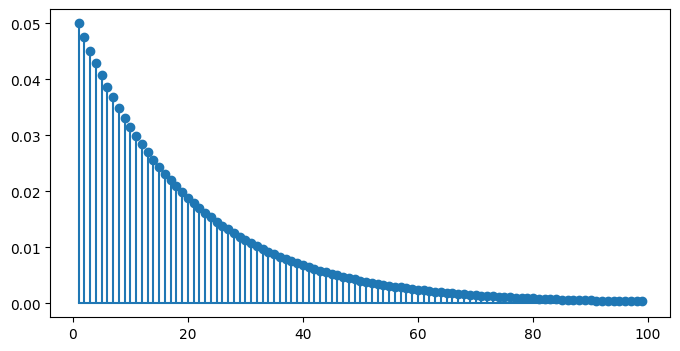

In [12]:
# Ahora vamos a graficar la distribución geometrica

from scipy.stats import geom

# El parámetro es
p = 0.05

#Valores posibles
x = np.arange(1,100) # de 1 a 20 ensayos

pmf_geo = geom.pmf(x,p)

plt.figure(figsize=(8,4))
plt.stem(x,pmf_geo, basefmt="") # baras verticales
plt.show()

# Variable Aleatoria Binomial Negativa $X \sim \text{BN}(r, p)$

La distribución **Binomial Negativa** describe procesos donde el número de éxitos está predeterminado ($r$), y nuestra incertidumbre recae sobre cuántos intentos totales ($X$) necesitaremos realizar para alcanzar dicha meta.

Supongamos que se realizan ensayos independientes, cada uno con probabilidad $0<p<1$ de ser un éxito, hasta obtener un total de $r$ éxitos acumulados. Sea $X$ el número de ensayos que se requieren, entonces la probabilidad de que el éxito número $r$ ocurra exactamente en el ensayo $k$ es:

$$f_{X}(k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$$

Donde:
- El valor de $k$ pertenece al conjunto $\{r, r+1, r+2, \dots\}$.
- El parámetro de Forma ($r$): representa el número de éxitos acumulados que deseamos obtener ($r \geq 1$).
- El parámetro de Intensidad ($p$): es la probabilidad de éxito en cada ensayo independiente ($0 < p < 1$).

### Función de distribución (CDF)

En forma acumulada:

$$F_{X}(x)=\begin{cases}
	0 &\quad x < 0 \\
	\sum_{k=0}^{|x|}\binom{k-1}{r-1} p^r (1-p)^{k-r} &\quad x \geq 0  
\end{cases}$$

### Esperanza y varianza

El valor promedio esperado de ensayos totales es:
$$\mathbb{E}[X] = \frac{r}{p}$$
 Y la varianza mide la dispersión de los ensayos necesarios:
$$\text{Var}[X] = \frac{r(1-p)}{p^2}$$

## Aplicaciones en Ciencia de Datos y Estadística

### 1. Control de Calidad y Procesos Industriales

Imagina que eres un ingeniero en una fábrica y necesitas recolectar **10 piezas defectuosas** $r = 10$ para analizar por qué fallan. Si sabes que la probabilidad de que una pieza salga mal es $p = 0.01 $:

- **¿Para qué sirve?** Para calcular cuántas piezas totales tendrás que inspeccionar en promedio antes de completar tu muestra.

- **Cálculo:** $$\mathbb{E}[X] = 10 / 0.01 = 1{,}000 $$ piezas. Esto te ayuda a presupuestar el tiempo de inspección.

### 2. Estrategias de Marketing y Ventas

Un vendedor necesita cerrar **5 ventas** $r = 5$ para llegar a su cuota diaria. Por experiencia, sabe que tiene una probabilidad de éxito del 20%, es decir, $p = 0.2$ por cada llamada.

- **¿Para qué sirve?** Para determinar cuántas llamadas debe hacer. El modelo le dirá que en promedio hará 25 llamadas, pero la **Varianza** le advertirá que hay días "malos" donde podría necesitar 40 o 50 llamadas para lograr el mismo objetivo.

### 3. Epidemiología y Salud Pública

Se usa para modelar el número de personas expuestas a un virus hasta que se encuentran $r$ casos positivos.

- **¿Para qué sirve?** Ayuda a entender la propagación de enfermedades. Si el virus es muy contagioso ($p$ alta), llegaremos a los $r$ casos rápido. Si la varianza es alta, la enfermedad es impredecible ("super-propagadores").

### 4. Modelado de "Sobredispersión" (Uso Avanzado)

En estadística de datos (Data Science), muchas veces usamos la **Binomial Negativa** cuando la **Distribución de Poisson** falla.

- En Poisson, la media es igual a la varianza.

- En la vida real (como clics en un anuncio o llegadas de clientes), la varianza suele ser mucho mayor que la media. La Binomial Negativa permite ajustar modelos donde los datos están muy dispersos.

### 5. Modelado de Tiempos de Espera

Se usa para predecir cuándo se completará una muestra de datos (ej. "necesitamos 100 encuestas válidas, ¿cuánta gente debemos contactar?").

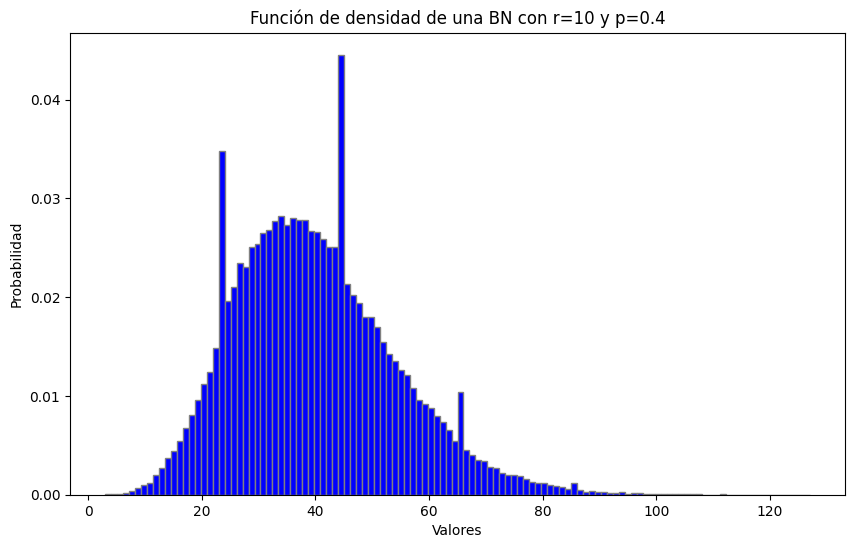

In [13]:
r = 10
p = 0.2 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla (para reproducilibilidad)
#Vamos a generar numeros aleatorios que siguen una distribución BN
nbinom_numeros = sps.nbinom.rvs(r,p,size=s)

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey"
)

plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=10 y p=0.4')
plt.show() #mostrar el gráfica

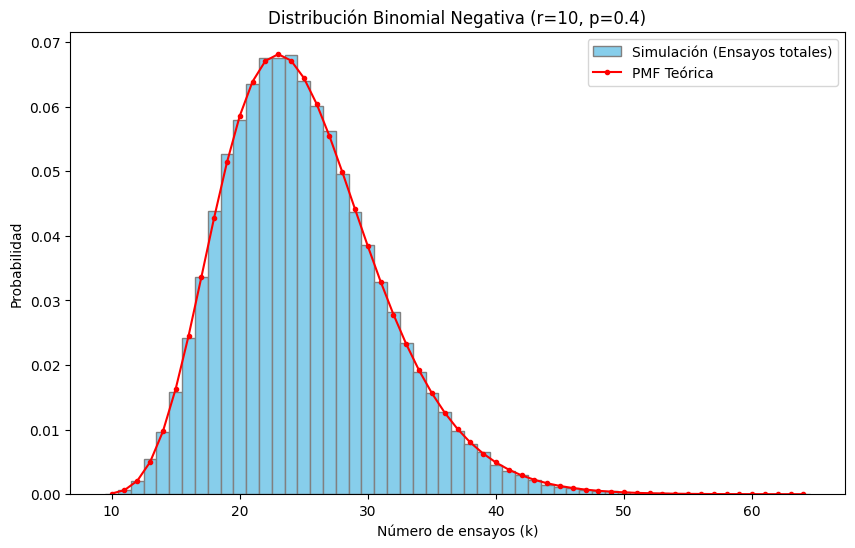

In [14]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import random

r = 10
p = 0.4
s = 100000

np.random.seed(3) # Es preferible usar np.random.seed para funciones de numpy/scipy

# 1. Generamos los fracasos y SUMAMOS r para obtener ensayos totales
nbinom_fracasos = sps.nbinom.rvs(r, p, size=s)
nbinom_ensayos = nbinom_fracasos + r

# 2. Creamos el histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_ensayos,
    density=True,
    bins=np.arange(r, np.max(nbinom_ensayos) + 1) - 0.5, # Centramos las barras
    color="skyblue",
    edgecolor="grey",
    label='Simulación (Ensayos totales)'
)

# 3. Superponemos la PMF teórica para validar
x_teorico = np.arange(r, np.max(nbinom_ensayos))
# Usamos x_teorico - r porque la PMF de scipy pide fracasos
pmf_teorica = sps.nbinom.pmf(x_teorico - r, r, p)

plt.plot(x_teorico, pmf_teorica, 'ro-', markersize=3, label='PMF Teórica')

plt.xlabel('Número de ensayos (k)')
plt.ylabel('Probabilidad')
plt.title(f'Distribución Binomial Negativa (r={r}, p={p})')
plt.legend()
plt.show()

$\color{red}{\text{Ejercicio 2.}}$ Un examen de Estadística consta de 20 preguntas tipo test y se conoce de experiencias
anteriores que un alumno tiene probabilidad 0.7 de contestar bien cada pregunta. Obtener:

a) La probabilidad de que la primera pregunta que contesta bien sea la cuarta.

b) Sabiendo que para aprobar el examen es necesario contestar bien a 10 preguntas, ¿cuál es la probabilidad de que apruebe al contestar la pregunta duodécima?

$\color{red}{\text{Ejercicio 3.}}$ Investigue sobre el problema de la caja de cerillos de Banach y explique su solución (sin simulación).

## Variable aleatoria Hipergeométrica con parámetros $n,N,m$.

Supongamos que se elige, **sin reemplazo**, una muestra de tamaño $n$ de una urna que contiene $N$ bolas, de las cuales $m$ son rojas y $N-m$ son verdes. Sea $X$ el número de bolas rojas seleccionadas, entonces su función de masa de probabilidades está dada por:
$$f_{X}(i)=
	\frac{\binom{m}{i}\binom{N-m}{n-i}}{\binom{N}{n}} \quad \text{si } i=0,1,\dots, n  
$$
Donde
- Los valores posibles de $X$ son
$$ i=\max\{0,n-(N-m)\},\dots,\min\{n,m\}. $$

Notación. $X\sim \text{Hiper}(n,N,m)$.

Se tiene que
$$\mathbb{E}[X]=\frac{nm}{N}$$
y
$$\text{Var}[X]=\frac{nm}{N}\left[\frac{(n-1)(m-1)}{N-1}+1-\frac{nm}{N} \right].$$

Equivalentemente,

$$
\mathrm{Var}(X)=n\frac{m}{N}\left(1-\frac{m}{N}\right)\frac{N-n}{N-1}.
$$

**Nota.** Si $i\leq n$ y $X\sim \text{Hiper}(n,N,m)$, con $p=\frac{m}{N}$ y $m,N$ son muy grandes con respecto a $n$ e $i$, entonces
$$\mathbb{P}(X=i)\approx \binom{n}{i}p^{i}(1-p)^{n-i}.$$

Es decir, en poblaciones muy grandes, la distribución hipergeométrica puede aproximarse por una distribución binomial.

$\color{red}{\text{Ejercicio 4.}}$ Ejercio replicar la grafica de la función de densidad

$\color{red}{\text{Ejercicio 5.}}$ Una compañía petrolera realiza un estudio geológico que indica que un pozo petrolero exploratorio debería tener un 20% de posibilidades de encontrar petróleo.

- ¿Cuál es la probabilidad de que el primer pozo se produzca en el tercer pozo perforado?

- ¿Cuál es la probabilidad de que el tercer pozo se produzca en el séptimo pozo perforado?

- ¿Cuál es la media y la varianza del número de pozos que se deben perforar si la compañía petrolera quiere establecer tres pozos productores?

## Variables aleatorias (absolutamente) continuas

## Variable aleatoria exponencial con parámetro $\lambda >0$.

### Aplicación:

La distribución exponencial es una de las distribuciones continuas más utilizadas. A menudo se utiliza para modelar el tiempo transcurrido entre eventos.  

Algunos ejemplos en los que podría utilizarse la distribución exponencial son:
* El tiempo transcurrido en un call center hasta recibir la primer llamada del día.
* El  tiempo entre terremotos de una determinada magnitud.
* Supongamos una máquina que produce hilo de alambre, la cantidad de metros de alambre hasta encontrar una falla en el alambre se podría modelar como una exponencial.

### Función de densidad (PDF):

Se dice que la variable aleatoria $X$ tiene distribución exponecial de parámetro $\lambda>0$, si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
\lambda e^{-\lambda x} & x>0\\
0 & \text{en otro caso}
\end{cases}$$


Notación. $X\sim \exp(\lambda).$

$\textbf{Propiedad de pérdida de memoria:}$
$$\mathbb{P}(X>t+s \mid X>t)=\mathbb{P}(X>s)=e^{-\lambda s}.$$

Ejercicio: Demostrar la propiedad de pérdida de memoria para $X\sim \exp(\lambda)$.

### Esperanza y varianza:

La esperanza y varianza de de una distribución exponencial de la forma $$f_{X}(x)=\begin{cases}
\frac{1}{\lambda} e^{-\frac{x}{\lambda}} & x>0\\
0 & \text{en otro caso}
\end{cases}$$:
$$\mathbb{E}[X]= \int_{0}^{\infty}xf_{x}(x)dx = \int_{0}^{\infty}x\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx = \lambda$$
y
\begin{align*}
\text{Var}(X) &= \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \int_{0}^{\infty}x^{2}f_{x}(x)dx-\lambda^{2} \\ &= \int_{0}^{\infty}x^{2}\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx - \lambda^{2} = \lambda^{2}
\end{align*}

### Función de distribución (CDF):
Se tiene que la función de distribución de la v.a. exponencial:

$$ F_{X}(x) = \mathbb{P}(X\le x) = \int_{0}^{x}\lambda e^{-\lambda u} du = 1- e^{-\lambda x}$$







**Ejemplo**

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila  de una sucuarsal bancaria.

Adicionalmente, el banco ha determinado que solo el $10\%$ de las veces, el tiempo que transcurre entre la llegada de una persona y otra es mayor a dos minutos.

Esto permite calcular el valor de $\lambda$, ya que
$$\mathbb{P}(X>2)=0.1$$
entonces
$$1-\mathbb{P}(X\le 2) = 1-F_{X}(2) = 0.1$$

Notemos que si $X\sim Exp\left( \lambda \right)$, entonces
$$F_{X}(x) = 1-e^{-\frac{x}{\lambda}} $$


Por lo que $F_{X}(2)= 1-e^{\frac{-2}{\lambda}} =0.9$, entonces
$e^{\frac{-2}{\lambda}}=0.1$. Por lo que
$$\frac{-2}{\lambda}=\ln(0.1) \Rightarrow \lambda=0.87$$
Por lo tanto $X\sim\exp(0.87)$.

Ahora queremos calcular la probabilidad de que entre la llegada de una persona y otra transcurra por lo menos un minuto, lo cual puede calcularse de dos formas:

\begin{align*}
\mathbb{P}(X>1) &= \int_{1}^{\infty}f_{X}(x)dx = \int_{1}^{\infty}\frac{1}{0.87}e^{\frac{-x}{0.87}}dx = 0.32
\end{align*}

\begin{align*}
\mathbb{P}(X>1) &= 1-\mathbb{P}(X\le 1) = 1-\left[1-e^{\frac{-1}{0.87}}\right] = e^{\frac{-1}{0.87}}
\end{align*}


$\color{red}{\text{Ejercicio 2.}}$ Calcular las probabilidades con Scipy

Una propiedad interesante de la distribución exponencial es que puede verse como un análogo continuo de la distribución geométrica. Para ver esto, recuerde el experimento aleatorio detrás de la distribución geométrica: lanza una moneda (repite un experimento de Bernoulli) hasta que observa las primeras caras (éxito).


$\mathbf{Teorema.-}$ Sea $\varepsilon>0$ y $Y_{\epsilon}\sim Geo(p_{\varepsilon})$. Supongamos que nos encontramos en el regimen:
$$\lim_{\varepsilon\to 0}p_{\varepsilon}=0 \qquad \text{y} \qquad \varepsilon^{-1}p_{\varepsilon}\sim \lambda>0$$
   Sea $X_{\varepsilon}:=\varepsilon Y_{\varepsilon}$. Entonces,
   $$\lim_{\varepsilon\to 0}F_{X_{\varepsilon}}(x)=F_{X}(x),$$
   en donde $X\sim \exp(\lambda)$. Este también es un resultado de convergencia en ley.

# Variable aleatoria normal con parámetros media $\mu$ y varianza $\sigma^{2}$.

La distribución normal es una de las más importantes y de mayor uso tanto en la teoría de la probabilidad, como en la teoría estadística.

También llamada distribución gaussiana, en honor a Gauss, a quien se considera el padre de ésta distribución.

La importancia de la distribución normal, radica en el famoso Teorema central del límite. Fue descubierta por De Moivre en 1733 como un límite de la distribución binomial.


La importancia de esta distribución radica en que permite modelar numerosos fenómenos naturales, sociales y psicológicos, por ejemplo:
* Estatura
* Efectos de un fármaco
* Consumo de cierto producto por un grupo de individuos
* Coeficiente intelectual
* Nivel de ruido en telecomunicaciones
* Errores cometidos al medir ciertas magnitudes

Además, esta distribución juega un papel de suma importancia en la inferencia estadística.

Se dice que la variable aleatoria $X$ tiene distribución normal de parámetros $\mu$ y $\sigma^{2}$, donde $\mu,\sigma\in\mathbb{R}$ y $\sigma>0$, si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
	\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}} &\quad \text{si }  x \in\mathbb{R} \\
	\qquad 0 &\quad \text{e.o.c}  
\end{cases}$$

**Notación.** $X\sim N(\mu,\sigma^{2})$


Tal curva (**la campana de Gauss-Bell**) es una función que depende de los parámetros $\mu$ y $\sigma^{2}$.


**Observación:** El parámetro $\mu$ se llama *media* y el  parámetro $\sigma^{2}$ se llama *varianza*.

La función de densidad definida anteriormente es efecto función de densidad, ya que
$$\int_{\mathbb{R}}f_{X}(x)dx = \int_{\mathbb{R}}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-m)^{2}}{2\sigma^{2}}}  = 1 $$

Variable aleatoria normal con parámetros  0  y  1 .
La ley de $Z\sim N(0,1)$ está dada por la función de densidad
$$
f_{Z}(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}},
$$
para $z\in \mathbb{R}$.

Sabemos que:
* La varianza es usada como una medida para comparar la dispersión en dos o más conjuntos de observaciones.
* Una desviación estándar pequeña indica que los valores de la variable aleatoria se encuentran cercanos a la media.
* Una desviación estándar grande indica que los valores de la variable aleatoria se dispersan mucho con respecto a la media.

### Función de distribución

La función de distribución de una variable aleatoria $X\sim N(\mu,\sigma^{2})$ está dada por:
$$F_{X}(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(y-\mu)^{2}}{2\sigma^{2}}}dy$$

Esta nos proporciona la probabilidad de que $X$ tome calores menores o iguales a un valor específico $x$, y corresponde al área bajo la curva en el intervalo $(-\infty,x]$:

No es sencillo calcular $F_{X}(x)$, pero cualquier v.a. gaussiana puede transformarse a una v.a. estandarizada. Existen tablas para esta v.a., lo cual hace los cálculos más fáciles.

**Proposición**  Sea $X\sim N(\mu,\sigma^{2})$, entonces
$$Z=\frac{X-\mu}{\sigma}$$
tiene una distribución gaussiana con media $0$ y varianza $1$, es decir, $Z\sim N(0,1)$.


**Demostración** 	Primero vamos a calcular la función de distribución de $Z$:
$$F_{Z}(z):=\mathbb{P}(Z\le z) = \mathbb{P}\left(\frac{X-\mu}{\sigma}\le z\right) = \mathbb{P}(X\le \sigma z + \mu) := F_{X}(\sigma z + \mu)$$
Entonces, la función de densidad de $Z$ esta dada por:
$$f_{Z}(z) = \frac{dF_{Z}(z)}{dz} = \frac{dF_{X}(\sigma z + \mu)}{dz} = \sigma f_{X}(\mu+\sigma z) = \frac{e^{-z^{2}/2}}{\sqrt{2\pi}}$$

Podemos calcular cualquier probabilidad de la forma
$$\mathbb{P}(a<X<b)$$
de la siguiente manera: para $z\ge 0$, definimos
$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}e^{-x^{2}/2}dx.$$


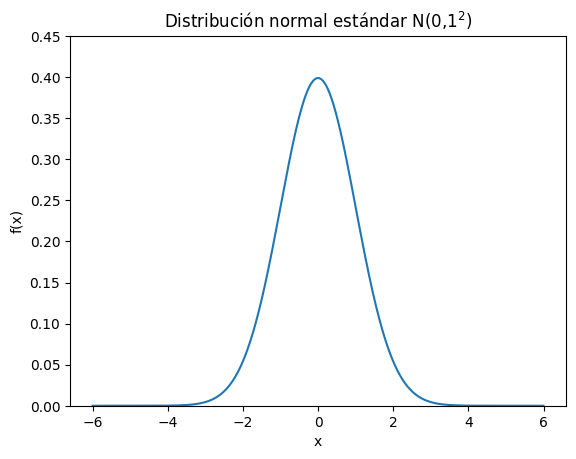

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm #importar la distribución normal
fig, ax = plt.subplots()
x= np.arange(-6,6,0.001) #generar valores de x
ax.set_title('Distribución normal estándar N(0,$1^2$)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.plot(x, norm.pdf(x)) # se grafica la función de densidad
ax.set_ylim(0,0.45)
plt.show()

Propiedades de la función de densidad de probabilidades de una distribución normal estándar:

1. Es positiva: $f(x)\geq 0$ para todo $x$ real.
2. Es continua y derivable en todas partes.
3. Es simétrica alrededor de $\mu$.
4. Conforme $x$ toma valores muy grandes de manera positiva y negativa, la función decrece hacia cero muy rápidamente.
5. Tiene un máximo global.
6. El área total bajo la curva es igual a $1$.

Veamos el comportamiento de la función conforme se cambia la varianza.

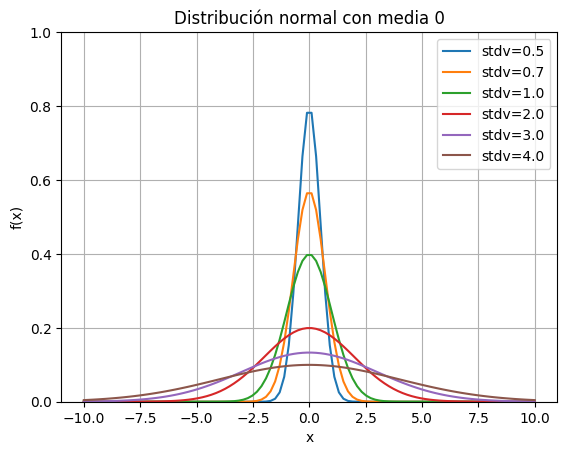

In [16]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100) # valores de x entre -10 y 10 (funciona como el dominio)
stdvs = [0.5, 0.7, 1.0, 2.0, 3.0, 4.0]
for s in stdvs:
    ax.plot(x, norm.pdf(x,scale=s), label='stdv=%.1f' % s)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Distribución normal con media 0')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,1)
ax.grid(True)

Veamos el comportamiento de la función conforme se cambia la media.

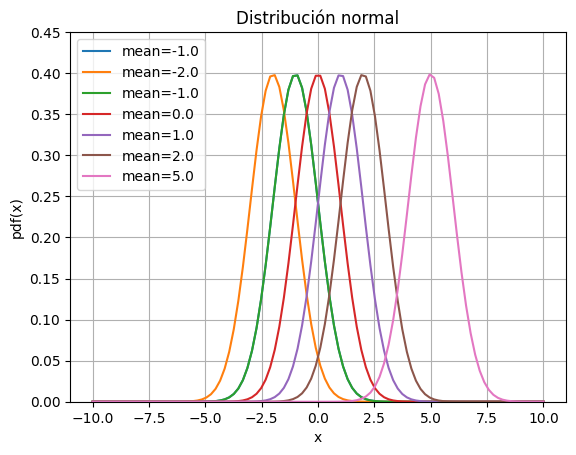

In [17]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
means = [-1.0,-2.0, -1.0, 0.0, 1.0, 2.0, 5.0]
for mean in means:
    ax.plot(x, norm.pdf(x,loc=mean), label='mean=%.1f' % mean)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,0.45)
ax.grid(True)

### Función de distribución de una normal $N(\mu,\sigma^2)$.

Gracias a las propiedades anteriores, es posible calcular áreas delimitadas de la función $f$. Si $a$ y $b$ son reales cualesquiera, denotaremos por
$$P(a\leq X\leq b),$$
la probabilidad de que $X$ esté en el intervalo $[a,b]$, al área bajo la curva de $f(x)$ sobre el intervalo $[a,b]$.

También, $P(X\leq x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(-\infty,x)$ y $P(X>x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(x, \infty)$.

A la probabilidad $\text{cdf}(x):=P(X\leq x)$ se llama la distribución acumulativa (hasta el valor $x$) de $f(x)$.

Con la notación anterior,
$$P(a\leq X\leq b)=\text{cdf}(b)-\text{cdf}(a)$$
y
$$\text{sf}(a):=P(X>a)=1-\text{cdf}(a).$$

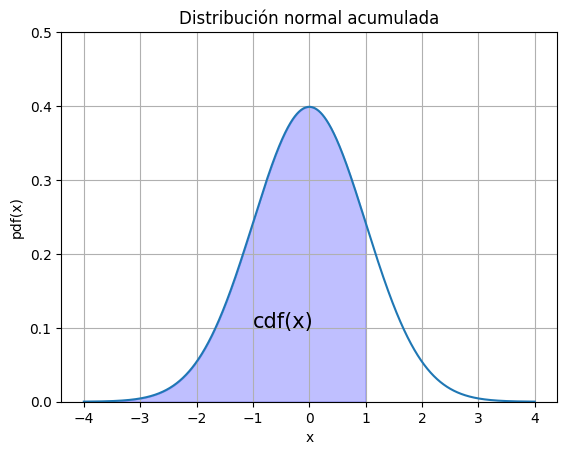

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, ax=plt.subplots()

# valores del eje horizontal
x = np.arange(-4,4,0.001)

ax.plot(x, norm.pdf(x))

ax.set_title("Distribución normal acumulada")
ax.set_xlabel("x")
ax.set_ylabel("pdf(x)")
ax.grid(True)

# Rellenamos el área bajo la curva
px = np.arange(-4,1,0.001) # desde -4 hasta 1
ax.set_ylim(0,0.5) # limites del eje vertical
ax.fill_between(px,norm.pdf(px),alpha=0.25, color='b') # rellenar
ax.text(-1,0.1,"cdf(x)",fontsize=15)
plt.show()

### Cálculo de probabilidades de una distribución normal



Calculemos $\text{cdf}(2)=\mathbb{P}(X\le2)$ cuando $X\sim N(3,2^2)$.

$$Z = \frac{X-\mu}{\sqrt{\sigma^2}} \sim N(0,1)$$

In [19]:
prob = norm.cdf(x=2, loc=3, scale=2)
print(prob)

0.3085375387259869


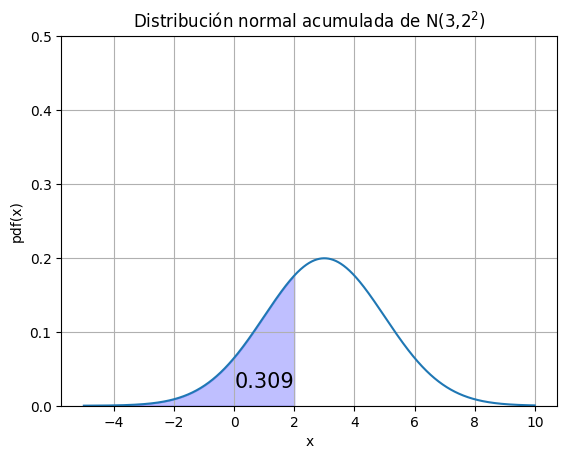

In [20]:
fig, ax=plt.subplots()
# valores del eje horizontal
x = np.arange(-5,10,0.001)
ax.plot(x, norm.pdf(x,loc=3,scale=2))

ax.set_title("Distribución normal acumulada de N(3,$2^2$)")
ax.set_xlabel("x")
ax.set_ylabel("pdf(x)")
ax.grid(True)

# Rellenamos el área bajo la curva
px = np.arange(-5,2,0.001) # desde -5 hasta 2
ax.set_ylim(0,0.5) # limites del eje vertical
ax.fill_between(px,norm.pdf(px,loc=3,scale=2),alpha=0.25, color='b') # rellenar
ax.text(0,0.025,round(norm.cdf(x=2, loc=3, scale=2),3),fontsize=15)
plt.show()

Calculemos $\mathbb{P}(0.5<𝑋<2)$ cuando $X\sim N(1,2)$.

In [21]:
s=np.sqrt(2)
norm(1, s).cdf(2) - norm(1,s).cdf(0.5)

np.float64(0.3984131339906417)

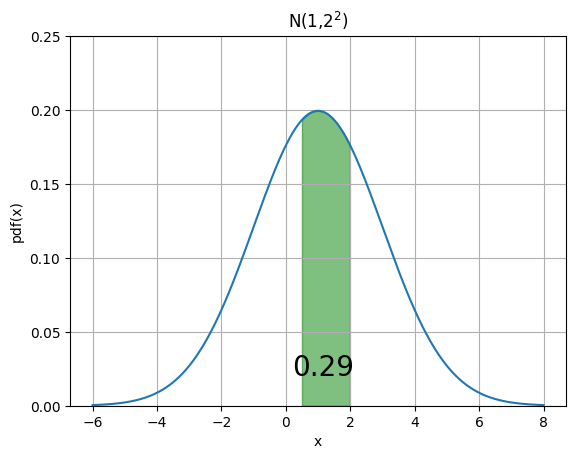

In [22]:
fig, ax = plt.subplots()
x= np.arange(-6,8,0.001)
ax.plot(x, norm.pdf(x,loc=1,scale=2))
ax.set_title("N(1,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(0.5,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=1,scale=2),alpha=0.5, color='g')
pro=norm(1, 2).cdf(2) - norm(1,2).cdf(0.5)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

**Ejemplo importante** Si $Z\sim N(0,1)$, encuentra $\mathbb{P}(-1.93 < Z < 1.93)$. La probabilidad buscada es:


In [23]:
norm(0,1).cdf(1.93)-norm(0,1).cdf(-1.93)

np.float64(0.9463931622458901)

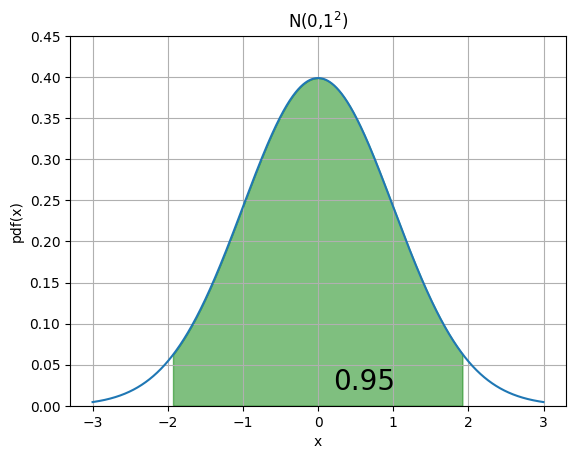

In [24]:
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-3,3,0.001)
ax.plot(x, norm.pdf(x,loc=0,scale=1))
ax.set_title("N(0,$1^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(-1.93,1.93,0.01)
ax.set_ylim(0,0.45)
ax.fill_between(px,norm.pdf(px,loc=0,scale=1),alpha=0.5, color='g')
pro=norm(0, 1).cdf(1.93) - norm(0,1).cdf(-1.93)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

### Cálculo de probabilidades:
$\mathbb{P}(0<Z<b)$: Queremos calcular $\mathbb{P}(0<Z<0.43)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(0<Z<0.43) = 0.1664$

$\mathbb{P}(-b<Z<b)$: Queremos calcular $\mathbb{P}(-0.16<Z<0.16)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha:  $\mathbb{P}(-0.16<Z<0.16) = \mathbb{P}(-0.16<Z<0)+\mathbb{P} (0<Z<0.16) = \mathbb{P}(0<Z<0.16)+\mathbb{P}(0<Z<0.16) = 2\mathbb{P}(0<Z<0.16) = 2(0.0636) = 0.1272$

$\mathbb{P}(Z<-b)$: Queremos calcular $\mathbb{P}(Z<-1.94)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z<-1.94) = \mathbb{P}(Z<0)+\mathbb{P}(-1.94<Z<0) = \mathbb{P}(Z<0) + \mathbb{P}(0<Z<1.94) = 0.5 - 0.4738 = 0.0262$

$\mathbb{P}(Z>-b)$: Queremos calcular $(Z>-0.07)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z>-0.07) = \mathbb{P}(-0.07<Z<0) + \mathbb{P}(Z>0) = \mathbb{P}(0<Z<0.07) + \mathbb{P}(Z>0) = 0.0279 + 0.5 = 0.5279$

![image.png](attachment:a82cec62-55bd-48ca-aac6-78e497b7c88c.png)

![image.png](attachment:013175cd-8c9a-481e-bf06-2ba7cb209b66.png)

## Variable aleatoria Gamma con parámetros $\alpha$ y $\lambda$.

 La distribución gamma se obtiene al considerar el tiempo que transcurre entre cierto número de ocurrencias de eventos que ocurren aleatoriamente en el tiempo

La función gamma $\Gamma:(0,\infty)\to \mathbb{R}$ está definida como
	$$\Gamma(\alpha)=\int_{0}^{\infty}t^{\alpha-1}e^{-t}dt.$$



*Propiedades de la función gamma*.
- $\Gamma(\alpha)<\infty$ para cualquier $\alpha>0$.
- $\Gamma(\alpha+1)=\alpha\Gamma(\alpha)$.
- Si $n\geq 1$ $\Gamma(n)=(n-1)!$
- $\Gamma\left(\frac{1}{2} \right)=\sqrt{\pi}$.

### Función de densidad

 Si $\alpha$ y $\lambda$ son reales positivos, decimos que una variable aleatoria $X$ tiene distribución gamma con parámetros $\alpha$ y $\lambda$ si tiene por función de densidad:
	$$\displaystyle f_{X}(x)=\begin{cases}
	\displaystyle \frac{\lambda^{\alpha}x^{\alpha-1}e^{-\lambda x} }{\Gamma(\alpha)} & x>0\\
	0 & \text{en otro caso}
	\end{cases}$$
En esta caso, escribimos la información anterior como $X\sim \Gamma(\alpha,\lambda) $

Donde $\alpha$ es el parámetro de forma:
- si $\alpha<1$, la densidad es alta cerca del cero, y luego decrece.
- Si $\alpha = 1$, es la exponencial
- Si $\alpha >1$, la curva tiene una moda y tiene forma de campana hacia la derecha.
y $\lambda$ es el parametro de escala (como se estira o se encoge horizontalmente)

### Función de distribución (CDF) y supervivencia

En términos de la función gamma incompleta inferior $\gamma(·,·)$ y la gamma completa

$$F_{X}(x) = \frac{\gamma(\alpha, \lambda x)}{\Gamma(\alpha)}$$

con $x\geq 0$

### Esperanza y varianza

La esperanza para una variable aleatoria $X\sim Γ(\alpha, \lambda)$ es:
$$
\mathbb{E}(X) = \frac{\alpha}{\lambda}
$$
y su varianza es:
$$
\text{Var}(X) = \frac{\alpha}{\lambda^2}
$$



**Ejemplo 1.** Una computadora cuántica cuenta con un tipo de aparato de medición, el cual tiene un tiempo de vida que se distribuye exponencialmente, de tal manera que su tiempo promedio de vida es de  $1000$ horas. Si se utilizan $10$ de estos aparatos en forma consecutiva, uno de ellos después de que el anterior ya no funciona. ¿Cuál es la probabilidad de que alguno de los aparatos estará funcionando después de $10,000$ horas?


**Solución.**
Sea $X$ el tiempo total de vida de los $10$ aparatos, usados, como se indica, uno después del otro. Entonces $X\sim \Gamma(10, 0.001)$. Así,
$$\mathbb{P}(X>10000)=\int_{10000}^{\infty}\frac{(0.001)^{10}}{9!}x^{9}e^{-0.001x}dx=0.4579.$$

**Ejemplo 2.**  Consideremos un call center donde los tiempos entre llamadas son independientes y se distribuyen exponencialmente con una media de 3 minutos. Supongamos que queremos encontrar la probabilidad de que transcurran más de 30 minutos antes de recibir 10 llamadas.


**Solución.**
Sea $X$ el tiempo total para recibir $10$ llamadas. Dado que el tiempo medio entre llamadas es de $3$ minutos. Entonces $X \sim \Gamma(10, \frac{1}{3})$. Así
$$P(X > 30) = \int_{30}^{\infty} \frac{\left(\frac{1}{3}\right)^{10} x^{9} e^{-\frac{x}{3}}}{9!} \, dx = 0.45793.$$

La esperanza para una variable aleatoria $X\sim Γ(\alpha, \lambda)$ es:
$$
\mathbb{E}(X) = \frac{\alpha}{\lambda}
$$
y su varianza es:
$$
\text{Var}(X) = \frac{\alpha}{\lambda^2}
$$


La distribución gamma es esencial en varios campos por su capacidad para modelar tiempos de espera y eventos con tasas constantes. Sus aplicaciones incluyen:

  * $\textbf{Teoría de colas y procesos estocásticos:}$ Modela el tiempo de espera hasta el k-ésimo evento.
  * $\textbf{Confiabilidad y análisis de supervivencia:}$ Utilizada para tiempos de fallo y eventos críticos en medicina.
  * $\textbf{Hidrología y meteorología:}$ Aplica en la modelación de precipitaciones acumuladas y tamaños de gotas.
  * $\textbf{Procesamiento de imágenes y señales:}$ En el ajuste de modelos a datos de intensidades.
  * $\textbf{Finanzas:}$ Para rendimientos de activos que no siguen distribuciones normales.
  * $\textbf{Biología y ecología:}$ Para tasas de crecimiento y tiempos entre eventos biológicos.
  * $\textbf{Física:}$ Describe tiempos de decaimiento y distribuciones de energía.


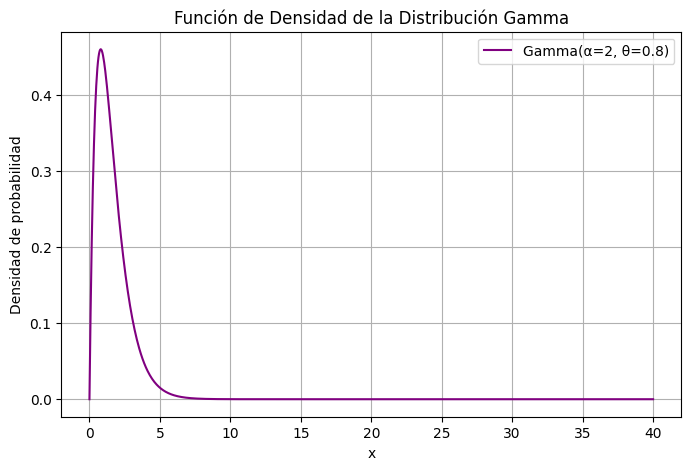

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Parámetros de la distribución Gamma
shape_param = 2  # Parámetro de forma (k o α)
scale_param = 0.8  # Parámetro de escala (θ o lambda)

# Generar valores de x
x = np.linspace(0, 40, 1000)

# Calcular la PDF de la distribución Gamma
gamma_pdf = gamma.pdf(x, a=shape_param, scale=scale_param)

# Graficar la PDF de la distribución Gamma
plt.figure(figsize=(8, 5))
plt.plot(x, gamma_pdf, label=f'Gamma(α={shape_param}, θ={scale_param})', color='purple')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad de la Distribución Gamma')
plt.grid(True)
plt.legend()
plt.show()

- Si $\alpha = 1$, $\lambda > 0 \Rightarrow$ v.a. exponencial.

- Si $\lambda = \frac{1}{2}$, $\alpha = \frac{k}{2}$, $k \in \mathbb{Z}^{+} \Rightarrow$ ji-cuadrada.

- Si $\lambda > 1$ y $\alpha > 1 \Rightarrow$ Erlang $\Rightarrow$ aplicaciones.


**Ejemplo** Sea $X \sim \mathcal{N}(0,1)$. Demostrar que $ X^2 $ tiene una distribución gamma.

**Solución:** Para $z \geq 0$, se tiene que:

$$
\begin{align*}
F_{X^2}(z) &= P(X^2 \leq z) = P(-\sqrt{z} \leq X \leq \sqrt{z}) \\
&= F_X(\sqrt{z}) - F_X(-\sqrt{z}) \\
\end{align*}
$$
Derivando, obtenemos la función de densidad:

$$ f_{X^2}(z) = \frac{d}{dz} F_{X^2}(z) = \frac{1}{2\sqrt{z}} f_X(\sqrt{z}) + \frac{1}{2\sqrt{z}} f_X(-\sqrt{z}) $$

Como la densidad de $X$ es simétrica, se tiene que

$$ f_{X^2}(z) = \frac{1}{\sqrt{2\pi}} e^{-z/2} \frac{1}{2\sqrt{z}} = \frac{(1/2)^{1/2} z^{-1/2} e^{-z/2}}{\Gamma(1/2)}  \sim Gamma\left(\frac{1}{2}, \frac{1}{2}\right) $$

## Variable aleatoria Beta con parámetros $\alpha$ y $\beta$.


La distribución beta es una familia de distribuciones de probabilidad continua definida en el intervalo [0, 1]. Es particularmente útil para modelar variables que representan proporciones y porcentajes.

La función beta, $B(\alpha, \beta)$, se define como:

$$
B(\alpha, \beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1} dt = \frac{\Gamma(\alpha) \Gamma(\beta)}{\Gamma(\alpha + \beta)}
$$

La función de densidad de probabilidad de la distribución beta se expresa como:

$$
f_X(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)},
$$
con $x\in (0,1)$.

**Notación.** $X\sim \text{Beta}(\alpha, \beta)$.



### Esperanza y Varianza
Si $X\sim \text{Beta}(\alpha, \beta)$, entonces
  $$\mathbb{E}[X] = \frac{\alpha}{\alpha + \beta}$$
y
  $$\text{Var}(X) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}.$$





**Ejemplo.** Supongamos que un análisis sugiere que una nueva inversión tiene una alta probabilidad de éxito. Usando una distribución beta con $\alpha = 5$ y $\beta = 1$, entonces:

$$
f_{X}(x) = 5x^4, \quad \mathbb{E}[X] = \frac{5}{6}, \quad \text{Var}(X) = \frac{5}{252}
$$


**Aplicaciones en la Vida Real**

La distribución beta se utiliza en una variedad de campos, incluyendo:
- Finanzas: para modelar la variabilidad en tasas de retorno de inversiones.
- Mercadotecnia: para analizar proporciones de respuesta de consumidores.
- Ciencias de la salud: en la evaluación de la efectividad de tratamientos médicos.
- Ecología: para estimar proporciones en estudios de biodiversidad.

# Generación y uso de variables aleatorias

Daremos recopilación de métodos para generar variables aleatorias utilizados en simulación computacional. Se abordan distribuciones uniformes, exponenciales, normales, binomiales y Poisson, entre otras, así como técnicas como la transformada inversa y el método del rechazo.

Ejemplos comunes en simulación:
- Tiempo entre llegada de cada persona  
- Número de personas por minuto  
- Número de artículos por persona  
- Cantidad de dinero ganado cada hora  
- Tiempo de atención por cliente  
- Número de veces que la cajera solicita ayuda durante la jornada  
- Cantidad de gente que está formada  
- Número de personas que pagan con tarjeta

## Métodos de generación de números aleatorios rectangulares

La generación de variables aleatorias con esta distribución es importante porque las variables que tengan una distribución diferente, tendrán que usar a ésta como base.

- Cada posible resultado entre $a$ y $b$ tiene la misma probabilidad $1/n$.

Las variables generadas deben cumplir con:
- Los valores generados deben ser independientes y estar idénticamente distribuidos
- La secuencia generada debe ser lo más larga posible y ser reproducibles
- Debe permitir generar múltiples secuencias
- Que usen poca memoria

Históricamente se han usado cuatro tipos de métodos para generar sucesiones de números rectangulares:
- Métodos manuales
- Tablas de biblioteca
- Computación analógica
- Computación digital

### Generación pseudoaleatoria

La generación de los números aleatorios rectangulares debe realizarse a través de relaciones matemáticas de recurrencia. Por esta razón se consideran **pseudoaleatorios**, ya que el proceso para generarlos es determinístico.

Hay dos métodos que son los más utilizados para la generación. Ambos se basan en la siguiente definición:

**Definición.** Dos enteros $a$ y $b$ son congruentes módulo $m$ si su diferencia es un múltiplo entero de $m$ y se expresa como
$$𝑎 \equiv 𝑏 ( \text{𝑚o𝑑 } 𝑚)$$
Como consecuencia:
- $(a-b)$ es divisible entre $m$
- $a$ y $b$ dan el mismo residuo al ser divididos entre $m$


#### Método congruencial multiplicativo

Generar una secuencia de números pseudoaleatorios uniformes en el intervalo (0, 1) usando la siguiente fórmula recursiva:

$$n_{i+1} = a n_i \mod m$$
- $m$ debe ser tan grande como sea posible, dependiendo de los bits por palabra que maneje la computadora, descontando el bit del signo ($b$). Por lo tanto: $m = 2^b$
- $a$ debe satisfacer que $a \approx 2^{(b+1)/2}$ y que $a \equiv \pm 3 \mod 8$. La segunda expresión equivale a $( a-(\pm3 ) )$ es múltiplo de $8$.
- $n_0$: entero positivo impar menor a $m$
- El periodo será de longitud: $m/4$

In [26]:
# n0 : valor inicial
# a : multiplicador
# m : módulo (2^b)
# n : el número de numeros que quiero generar

def multiplicativo(n0,a,m,n):
    secuencia = [] # lista vacía para ir guardando los números generados
    ni = n0 # inicio con un valor inicial
    # Repetimos n veces
    for i in range(n):
        ni = (a* ni) % m # formula recurrente
        secuencia.append(ni/m) # agrego el numero a la lista normalizado
    return secuencia

In [27]:
# Ejemplo
m = 2**31
a = 65539 # a≡ +-3 (mod 8)
n0 = 123456789
n =1000

secuencia_mult = multiplicativo(n0,a,m,n)
print(secuencia_mult)

[0.7746705110184848, 0.1306216404773295, 0.8116952436976135, 0.6945766978897154, 0.8622029940597713, 0.9220276833511889, 0.7723391535691917, 0.3357857712544501, 0.06366224540397525, 0.35990153113380075, 0.5864489781670272, 0.2795800887979567, 0.3994397292844951, 0.8804175765253603, 0.687547895591706, 0.2015291848219931, 0.021244048606604338, 0.313701628241688, 0.691013331990689, 0.3227653377689421, 0.7174720386974514, 0.39994419226422906, 0.9424168053083122, 0.05500310147181153, 0.8482673610560596, 0.5945762530900538, 0.9330512690357864, 0.24712133640423417, 0.08526659710332751, 0.28750755498185754, 0.9576459559611976, 0.15830774093046784, 0.33103284193202853, 0.5614273832179606, 0.3892687219195068, 0.28276588255539536, 0.1931767980568111, 0.6141678453423083, 0.9464158895425498, 0.15098472917452455, 0.38816536916419864, 0.9701296524144709, 0.32728959200903773, 0.2325706803239882, 0.4498177538625896, 0.6057704002596438, 0.5862626167945564, 0.06564209843054414, 0.11748903943225741, 0.114

#### Método congruencial mixto

Este método genera números pseudoaleatorios con la fórmula:
$$n_{i+1} = (a n_i + c) \mod m$$

**Obs.** Se le llama “mixto” porque incluye una constante adicional $c$ (a diferencia del método multiplicativo).

- $m = 2^b$
- $a \approx 2^{(b-1)/2}$, $a \equiv 1 \mod 4$, es decir, $(a-1)$ es múltiplo de 4.
- $c$, $n_0$: enteros positivos impares menores a $m$
- Periodo: tiene longitud $m$

In [28]:
# n0 : valor inicial impar
# a : multiplicador
# c : constante (impar)
# m : módulo (2^b)
# n : el número de numeros que quiero generar

def mixto(n0,a,c,m,n):
    secuencia = []
    ni = n0
    for i in range(n):
        ni = (a* ni +c) % m # formula recurrente
        secuencia.append(ni/m)
    return secuencia

In [29]:
# Ejemplo
m = 2**31
a = 1103515245 # a≡ 1 mod 4
c = 12345
n0 = 41
n = 1000

secuencia_mixto = mixto(n0,a,c,m,n)
print(secuencia_mixto)

[0.06844326015561819, 0.9992314944975078, 0.4621392320841551, 0.9174640052951872, 0.5820055874064565, 0.37821047520264983, 0.2048243023455143, 0.18477003322914243, 0.4875209955498576, 0.8468507858924568, 0.47256272472441196, 0.9521327749826014, 0.45746100787073374, 0.17842541774734855, 0.5796984285116196, 0.36512060137465596, 0.8805065592750907, 0.48256447864696383, 0.8824073132127523, 0.42976788664236665, 0.7212892072275281, 0.22954718535766006, 0.48902439698576927, 0.25073418812826276, 0.0422417176887393, 0.4445157307200134, 0.4918553400784731, 0.11126030096784234, 0.2813080260530114, 0.29036102583631873, 0.5642223432660103, 0.3636711877770722, 0.8792625730857253, 0.7580303172580898, 0.2664944212883711, 0.5991757833398879, 0.3503890158608556, 0.683006679173559, 0.9048520512878895, 0.06571367429569364, 0.3902683136984706, 0.8067103805951774, 0.2865361962467432, 0.8025986538268626, 0.11442618910223246, 0.10157212754711509, 0.21533170342445374, 0.46070915134623647, 0.02158996369689703, 

| **Método**     | **Fórmula**                            | **Ventajas**                                          | **Riesgos / Limitaciones**                                |
|----------------|----------------------------------------|-------------------------------------------------------|------------------------------------------------------------|
| Multiplicativo | $n_{i+1} = a n_i \mod m $           | Rápido, menos memoria                                 | Menor aleatoriedad, requiere $(a, m, n_0)$ bien elegidos |
| Mixto          | $ n_{i+1} = (a n_i + c) \mod m $     | Mejor distribución, periodo completo posible          | Más complejo, pero más robusto                             |
| NumPy (`uniform`) | Motor moderno y validado           | Alta calidad, probado, rápido                         | Caja negra, sin control del generador interno              |


## Metodos de generación de numeros aleatorios no rectangulares

#### Método de la transformada inversa

El método utiliza la función de distribución $F(x)$ de la distribución que se va a simular
$$F(x) = \int_{-\infty}^{x} f(t)\,dt$$

![image.png](attachment:aeaa5ec8-f8cb-4c7d-89af-44a240c12c61.png)

Como se sabe, los valores de $F(x)$ están en el intervalo $(0,1)$ al igual que los números rectangulares $U$.

El método genera un $U$ y trata de determinar el valor de la variable aleatoria para la cual $F(x)$ sea igual a $U$.

Si $U \in (0,1)$:
$$ F(x) = U \quad \Rightarrow \quad x = F^{-1}(U)$$

![image.png](attachment:e7665e52-3ff6-474b-8d59-0027b66ef343.png)

$\mathbf{Teorema}.$ Sea $X$ una variable aleatoria real. Supongamos que su función de distribución $F$ es estrictamente creciente (por lo que $F$ es una biyección de $\mathbb{R}$ sobre $(0,1)$ y podemos denotar por $F^{-1}$ a su inversa). Sea $U\sim \text{unif}[0,1]$. Entonces $F^{-1}(U)$ tiene la misma ley que $X$.

Si $F$ no es estrictamente creciente, hemos visto que el teorema precedente sigue siendo válido bajo la condición de definir
$$F^{-1}(u)=\inf\{ x\in \mathbb{R} : F(x)\geq u\},$$
la inversa generalizada de $F$.

In [30]:
# Vamos a simular una v.a Bernoulli usando una uniforme
# Sabemos que X ~ Ber (p),  f(x)= p^x(1-p)^{1-x}

import random # numeros aleatorios
def bernoulli(p):
    U = random.random() # U -> Unif[0,1]
    if U <= p:
        return 1 # éxito
    else:
        return 0 # fracaso

In [31]:
# Simulamos  n valores con p de éxtito
p=0.5
numer = [bernoulli(p) for _ in range(10000)]
#print(numer)

In [32]:
print("El número de éxitos es:", sum(numer))

El número de éxitos es: 5004


In [33]:
import plotly.express as px # Para visualización interactiva
px.histogram(
    numer,
    x = numer,
    nbins = 2,
    title = "Sumulaciones de una Bernoulli con p=0.5",
    labels = {"x": "Valor de la Bernoulli (0-fracaso, 1-éxito)" }
)

## Ejemplo: Distribución exponencial

Sea $\lambda>0$, entonces a través del teorema se puede generar una v.a. exponencial.

Sea $U \sim Unif[0,1]$, entonces si $X\sim Exp(\lambda)$, entonces

$$f_{X}(x) = \lambda e^{-\lambda x}$$
y que
$$F_X(x) = 1 - e^{-\lambda x}$$

Sabemos que $1-e^{-\lambda x} = U$, entonces $1-U = e^{-\lambda x}$, y tomando logaritmo, se tiene que
$ \ln(1-U) = -\lambda x$ y como $U$ es uniforme entonces $U \sim 1-U$, por lo que depejando a $x$, se tiene que
$$ X = -\frac{\ln(U)}{\lambda} \sim Exp(\lambda) $$


In [34]:
import numpy as np
import plotly.graph_objects as go
# Fijamos una semilla
np.random.seed(123)

# Damos el parámetro de la distribución exponencial
lambd = 4

# Vamos a simular n=1000
n=10000

uniformes = np.random.random(n) # Generar n uniformes
exponenciales = -np.log(uniformes) / lambd # Transformada inversa

# Vamos a crear la curva de densidad teórica (exponencial)
x_vals = np.linspace(0, exponenciales.max(),300)
y_vals = lambd * np.exp(-lambd * x_vals) # densidad de Exp

fig = go.Figure()

fig.add_trace(go.Histogram(
    x = exponenciales,
    nbinsx= 40,
    histnorm = 'probability density',
    marker_color = 'skyblue',
    name = 'Simulación'
))
# agregar una linea
fig.add_trace(go.Scatter(
    x = x_vals,
    y = y_vals,
    mode = 'lines',
    name = 'Densidad Teórica',
    line = dict(color='darkblue')
))

fig.update_layout(
    title = "Distribución Exponencial simulada vs teórica (lambda = 4)",
    xaxis_title = 'x',
    yaxis_title = 'Densidad',
    bargap = 0.05 # espacio entre las barras
)

fig.show()

## Ejemplo: Distribución Uniforme Continua
$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$
$$F(x) = \frac{x-a}{b-a} = U \Rightarrow X = a + (b-a)U \sim Unif(a,b)$$

$\mathbf{Ejemplo}$ (Variable aleatoria Cauchy) Simulemos la variable aleatoria de Cauchy de parámetro $1$ que tiene por función de densidad
$$f_{X}(x) = \frac{1}{\pi}\frac{1}{1+x^{2}}, \quad x\in\mathbb{R}$$

**Ejercicio:**
- Corroborar que la función así definida es una función de densidad de probabilidad
- Encontrar $F_X$
- Crear una gráfica en Python que muestre su forma
- Generar v.a. Cauchy a partir de una uniforme

Por el teorema anterior, para $u\in (0,1)$
$$u=\frac{1}{\pi}\arctan(x)+\frac{1}{2} \qquad \text{si y sólo si} \qquad x=\tan\left({\pi}\left(u-\frac{1}{2} \right) \right).$$

# Introducción al Método de Monte Carlo
El concepto es simple: si no puedes calcular algo de forma analítica, "juega" a la probabilidad muchas veces y observa a qué valor tiende el promedio.

Imagina que alguien te pide calcular el área de una figura geométrica de forma tan irregular que ninguna fórmula conocida se aplica directamente. Un matemático buscaría una integral. Un estadístico haría algo completamente diferente: lanzaría dardos al azar y contaría cuántos caen dentro de la figura.

Esa intuición, aparentemente infantil, es la esencia del Método de Monte Carlo: resolver problemas deterministas — con una respuesta fija — mediante la generación masiva de números aleatorios.

Nacido en los laboratorios secretos de Los Álamos durante el Proyecto Manhattan, hoy es indispensable en finanzas cuantitativas, física de partículas, inteligencia artificial y ciencia de datos.

## 1. El origen: Los Álamos y una baraja de cartas

En 1945, el matemático Stanislaw Ulam se encontraba en cama recuperándose de una enfermedad. Para pasar el tiempo jugaba solitario y se preguntó cuál era la probabilidad de ganar. Calcularla combinatoriamente era casi imposible, pero pensó: ¿qué pasa si simplemente juego cientos de partidas y cuento cuántas gano?

Compartió la idea con John von Neumann, quien la formalizó matemáticamente. Juntos, con Nicholas Metropolis, la aplicaron a los cálculos de difusión de neutrones para la bomba atómica. Necesitaban mantenerla en secreto, así que le dieron el nombre en código de Monte Carlo en alusión al famoso casino de Mónaco frecuentado por un tío de Ulam.

**“El primer programa de Monte Carlo corrió en la computadora ENIAC en 1948. Tardó horas en completar simulaciones que hoy toman milisegundos en un smartphone”.**

## 2. Los fundamentos matemáticos

El método descansa sobre tres pilares teóricos sólidos de la probabilidad y la estadística: la **Ley de los Grandes Números**, el **Teorema Central del Límite**, y la **integración por muestreo**.

### 2.1 La Ley de los Grandes Números

Si repetimos un experimento aleatorio muchas veces, el promedio de los resultados converge al valor esperado real. Formalmente, para variables aleatorias $X_1, X_2, ..., X_n$ independientes e idénticamente distribuidas con esperanza finita $\mu$:

> **LEY DÉBIL DE LOS GRANDES NÚMEROS**
> $$\bar{X}_n = (X_1 + X_2 + ... + X_n) / n \to \mu \quad \text{cuando} \quad n \to \infty$$

Esta ley es la garantía teórica de que nuestras simulaciones, si corremos suficientes iteraciones, convergerán al valor verdadero. Monte Carlo explota esta propiedad deliberadamente.

### 2.2 El Teorema Central del Límite

Nos dice que la distribución del promedio muestral se aproxima a una **distribución normal**, sin importar la distribución original de los datos, a medida que $n$ crece. Esto nos permite construir intervalos de confianza para nuestras estimaciones Monte Carlo.

> **ERROR ESTÁNDAR DEL ESTIMADOR MONTE CARLO**
> $$\sigma / \sqrt{n} \approx \text{desviación estándar} / \sqrt{\text{número de simulaciones}}$$

Esta fórmula revela una verdad crítica: para reducir el error a la mitad, necesitamos cuatro veces más simulaciones. La convergencia de Monte Carlo es de orden $O(n^{-1/2})$, lo que lo hace robusto pero requiere potencia computacional.

### 2.3 Integración por Monte Carlo

El uso más directo del método es calcular integrales que son analíticamente intratables. Dada una función $f(x)$, su integral en $[a, b]$ se estima como:

> **ESTIMADOR DE INTEGRAL MONTE CARLO**
> $$\int_{a}^{b} f(x) \, dx \approx (b - a) \cdot (1/N) \cdot \sum_{i} f(x_i)$$

Donde los $x_i$ son puntos uniformes en $[a, b]$.

## 3. Anatomía de un algoritmo Monte Carlo

Todo método de Monte Carlo sigue la misma estructura en cuatro pasos:

  - **Definir el espacio de entrada**
    Identificar las variables aleatorias del problema y sus distribuciones de probabilidad (uniforme, normal, Poisson, etc.).
  - **Generar muestras aleatorias**
    Usar un generador de números pseudoaleatorios (PRNG) para samplear del espacio definido. La calidad del PRNG impacta directamente la confiabilidad del resultado.

  - **Ejecutar la función determinista**
    Evaluar el modelo o función para cada muestra generada.
    
  - **Agregar y analizar resultados**
     Calcular estadísticas (media, varianza, percentiles) sobre los resultados. Construir intervalos de confianza usando el TCL para cuantificar la incertidumbre.

### Ejemplo: Estimación de $\pi$
Imagina un cuadrado de lado $2r$ que contiene un círculo de radio $r$.
* El área del cuadrado es $(2r)^2 = 4r^2$.
* El área del círculo es $\pi r^2$.
* La razón entre las áreas es:
$$\frac{\text{Área del círculo}}{\text{Área del cuadrado}} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4}$$

Por lo tanto:  $\pi \approx 4 \times \left( \frac{\text{Puntos dentro del círculo}}{\text{Total de puntos}} \right)$

## 2. Implementación en Python

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def estimar_pi(n_puntos):
    # Generar puntos aleatorios en un plano 2D entre -1 y 1
    x = np.random.uniform(-1, 1, n_puntos)
    y = np.random.uniform(-1, 1, n_puntos)

    # Calcular la distancia al origen para cada punto
    distancia_al_origen = x**2 + y**2

    # Un punto está dentro del círculo si x^2 + y^2 <= 1
    dentro_del_circulo = distancia_al_origen <= 1

    # Cálculo de pi
    puntos_dentro = np.sum(dentro_del_circulo)
    pi_estimado = 4 * puntos_dentro / n_puntos

    return x, y, dentro_del_circulo, pi_estimado

<>:13: SyntaxWarning:

invalid escape sequence '\p'

<>:13: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_846/2280418046.py:13: SyntaxWarning:

invalid escape sequence '\p'



Resultados con 10000 puntos:
Valor estimado de π: 3.1676
Error relativo: 0.8278%


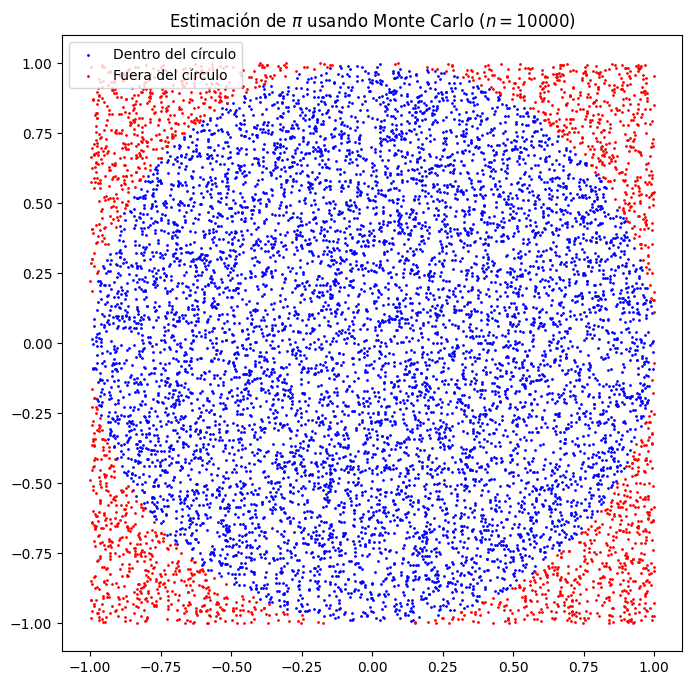

In [36]:
# Datos experimento
n = 10000
x, y, dentro, pi_final = estimar_pi(n) # dentro es un array booleano que indica si cada punto está dentro del círculo

print(f"Resultados con {n} puntos:")
print(f"Valor estimado de π: {pi_final}")
print(f"Error relativo: {abs(np.pi - pi_final) / np.pi * 100:.4f}%")

# Visualización
plt.figure(figsize=(8, 8))
plt.scatter(x[dentro], y[dentro], color='blue', s=1, label='Dentro del círculo')
plt.scatter(x[~dentro], y[~dentro], color='red', s=1, label='Fuera del círculo')
plt.title(f"Estimación de $\pi$ usando Monte Carlo ($n={n}$)")
plt.legend()
plt.show()

### Análisis de Convergencia

Una característica clave mencionada en el método es que la precisión aumenta con el número de iteraciones ($n$).

Vamos a ver como se "estabiliza" el valor:

<>:10: SyntaxWarning:

invalid escape sequence '\p'

<>:13: SyntaxWarning:

invalid escape sequence '\p'

<>:10: SyntaxWarning:

invalid escape sequence '\p'

<>:13: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_846/637861259.py:10: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_846/637861259.py:13: SyntaxWarning:

invalid escape sequence '\p'



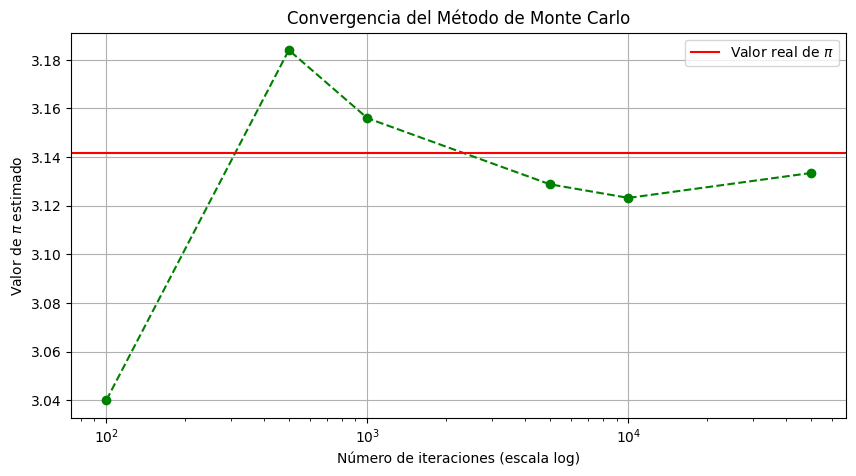

In [37]:
iteraciones = [100, 500, 1000, 5000, 10000, 50000]
resultados = []

for i in iteraciones:
    _, _, _, valor = estimar_pi(i)
    resultados.append(valor)

plt.figure(figsize=(10, 5))
plt.plot(iteraciones, resultados, marker='o', linestyle='--', color='green')
plt.axhline(y=np.pi, color='r', linestyle='-', label='Valor real de $\pi$')
plt.xscale('log')
plt.xlabel('Número de iteraciones (escala log)')
plt.ylabel('Valor de $\pi$ estimado')
plt.title('Convergencia del Método de Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()

En el mundo de las finanzas, el **Método de Monte Carlo** se utiliza para modelar la incertidumbre y predecir el comportamiento de activos (como acciones) a lo largo del tiempo.

A diferencia de un cálculo lineal, aquí simulamos miles de "caminos" posibles que podría tomar el precio de una acción basándonos en su **volatilidad** y **rendimiento esperado**.

## Simulación de Monte Carlo para Predicción de Precios de Acciones

Utilizaremos el modelo de **Movimiento Browniano Geométrico (GBM)**. La fórmula simplificada para el cambio en el precio es:

$$\Delta S = S \times (\mu \Delta t + \sigma \epsilon \sqrt{\Delta t})$$

Donde:
* $S$: Precio de la acción.
* $\mu$: Rendimiento esperado (drift).
* $\sigma$: Volatilidad (riesgo).
* $\epsilon$: Variable aleatoria con distribución normal.

### Código de Implementación

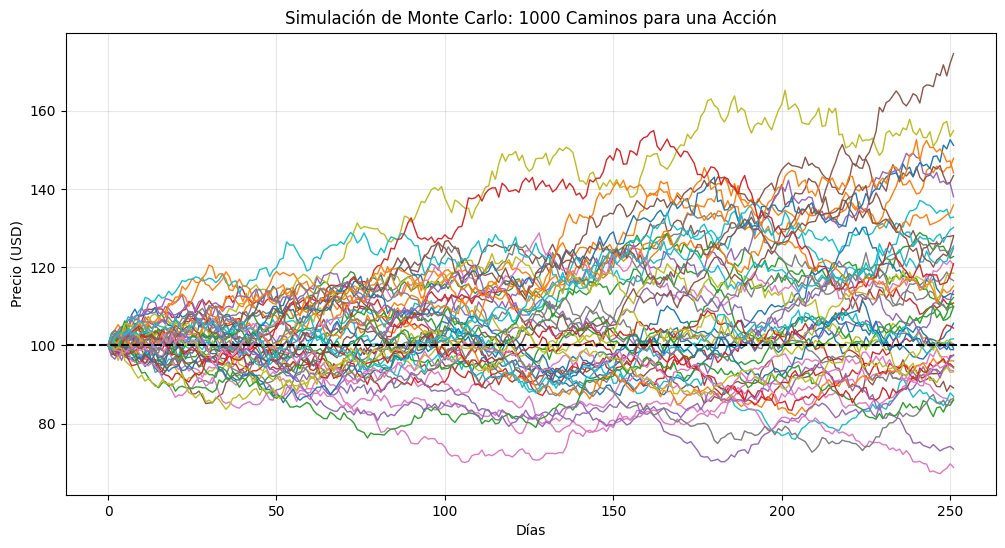

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Parámetros de la simulación
precio_inicial = 100    # Precio actual de la acción (USD)
t_final = 252           # Días de trading en un año
mu = 0.1                # Rendimiento anual esperado (10%)
volatilidad = 0.2       # Volatilidad anual (20%)
n_simulaciones = 1000   # Número de escenarios posibles

# 2. Configuración de tiempos
dt = 1 / t_final
precios = np.zeros((t_final, n_simulaciones))
precios[0] = precio_inicial

# 3. Ejecución de la simulación
for t in range(1, t_final):
    # Generar números aleatorios (shocks del mercado)
    epsilon = np.random.standard_normal(n_simulaciones)

    # Calcular el precio para el siguiente paso de tiempo
    precios[t] = precios[t-1] * np.exp((mu - 0.5 * volatilidad**2) * dt +
                                        volatilidad * np.sqrt(dt) * epsilon)

# 4. Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(precios[:, :50], lw=1) # Graficamos solo 50 rutas para no saturar
plt.axhline(y=precio_inicial, color='black', ls='--', label='Precio Inicial')
plt.title(f'Simulación de Monte Carlo: {n_simulaciones} Caminos para una Acción')
plt.xlabel('Días')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.show()

# La Ley de los Grandes Números (LGN)

### Simulación de la LGN:

Simularemos los lanzamientos de un dado y calcularemos la media:

$$\Omega = \{1,2,3,4,5,6\}$$
y además la media teórica es:

$$\mathbb{E}[X]=3.5$$

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
# Fijamos una semilla
np.random.seed(42) #para repoducilidad

# Vamos a simular 10,000 lanzamientos de un dado
lanzamientos = np.random.randint(1,7,10000) # entre 1 y 6

media_acum = np.cumsum(lanzamientos) / np.arange(1,10001) # media acumulada

df = pd.DataFrame({
    'Lanzamiento': np.arange(1,10001),
    'Media Acumulada': media_acum})
#df

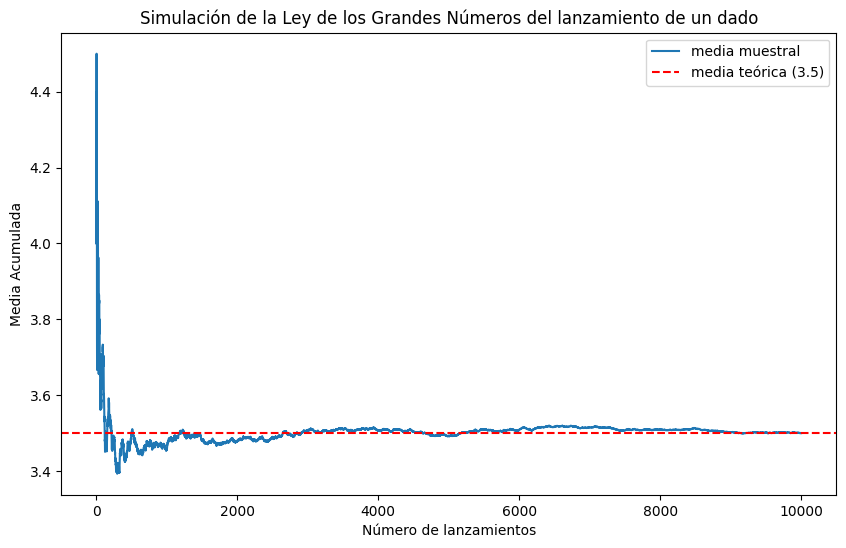

In [41]:
plt.figure(figsize=(10,6))
plt.plot(df['Lanzamiento'], df['Media Acumulada'], label = 'media muestral')
plt.axhline(3.5, color='red', linestyle='--', label = 'media teórica (3.5)')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Media Acumulada')
plt.title('Simulación de la Ley de los Grandes Números del lanzamiento de un dado')
plt.legend()
plt.show()

# Aplicacion de la ley de los Grandes Números

## El problema de la ajuga de Bufón

Estimación de pi: [3.1446540880503147, 3.1397174254317113, 3.1266284523189163, 3.127443315089914, 3.134796238244514, 3.1315240083507305, 3.11804008908686, 3.1335683509596555, 3.143006809848088, 3.1333228889237037, 3.1446540880503147, 3.138485680659082, 3.145795523290986, 3.147128245476003, 3.141032352633232, 3.142801021410332, 3.136820739920657, 3.138348879783803, 3.13686643552914, 3.1414434932851645, 3.143242029636282, 3.138373751783167, 3.1420765027322406, 3.1395120674995094, 3.1436655139893115, 3.149034094349906, 3.1503412869727554, 3.1531531531531534, 3.156290814105355, 3.158559696778269, 3.157626687038452, 3.1584661698662586, 3.1594064145524174, 3.157210511653821, 3.156708004509583, 3.160667251975417, 3.1592878794347437, 3.157588599443267, 3.1559781509204936, 3.155694055461323, 3.1534822905049418, 3.1539819021514663, 3.1520304940624544, 3.1480289046290335, 3.1477336317851146, 3.1473435736033664, 3.1464435146443517, 3.1467156155762424, 3.1450577663671373, 3.144851877476571, 3.14649

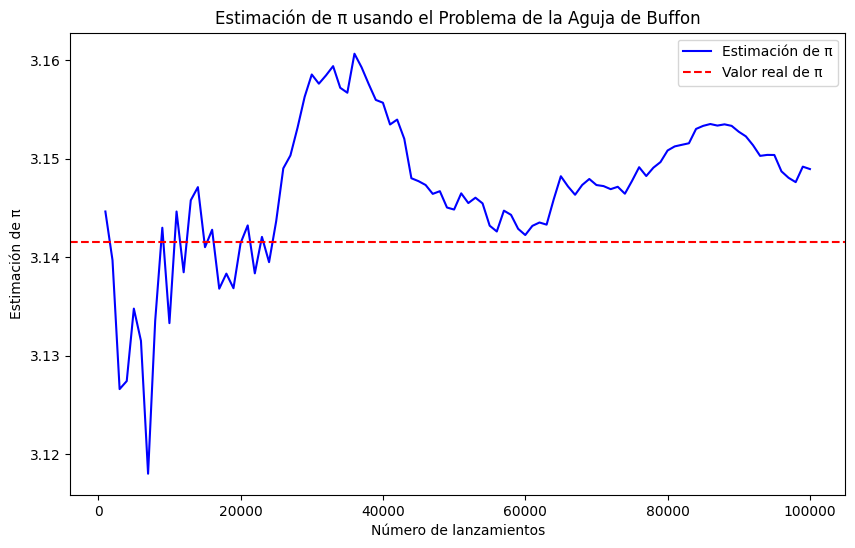

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
# Distancia entre las lineas paralelas de 1
# Longitud de la aguja de 1

L = 1 # longitud L<=d
d = 1 #distancia
num_lanzamientos = 100000

step = 1000 # numero de pasos

# Creamos listas vacías para guardar los resultados
pi_estimados = []
lanzamientos_realizados = []

# Contamos los cruces de la linea para saber cuantas agujas cruzan una línea
cruces = 0

# Simulación de los lanzamientos de la aguja y la estimación de pi
for i in range(1,num_lanzamientos+1):
    # Posicion del centro de la aguja
    centro = np.random.uniform(0,d/2)

    # Ángulo aleatorio entre 0 y pi
    angulo = np.random.uniform(0,np.pi)

    # Distancia desde el centro de la aguja hasta la línea más cercana
    distancia = (L/2) * np.sin(angulo)

    # Verificamos si la aguja cruza una línea
    if centro <= distancia:
        cruces += 1 # incrementar el contador

    # Estimación de pi
    if i % step == 0 and cruces > 0:
        pi_estimado = (2 * L * i) / (d * cruces)
        pi_estimados.append(pi_estimado)
        lanzamientos_realizados.append(i)

print(f"Estimación de pi: {pi_estimados}")

# Graficamos la estimación de pi
plt.figure(figsize=(10,6))
plt.plot(lanzamientos_realizados, pi_estimados, label='Estimación de π', color='blue')
plt.axhline(np.pi, color='red', linestyle='--', label='Valor real de π')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Estimación de π')
plt.title('Estimación de π usando el Problema de la Aguja de Buffon')
plt.legend()
plt.show()

# Teorema Central del Límite (TCL)

/tmp/ipykernel_846/2270062300.py:24: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




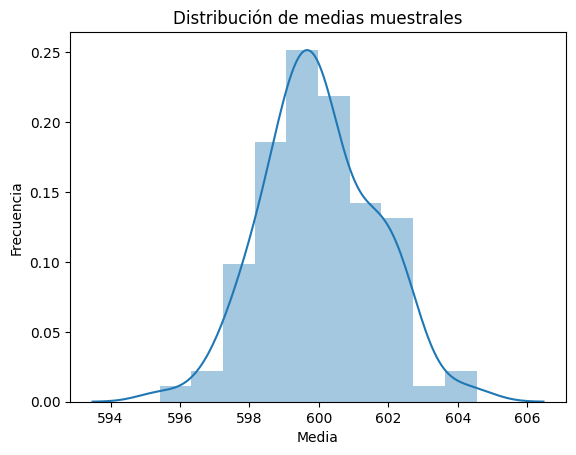

In [43]:
# Vamos a hacer una muestra (por ejemplo 100) cada una con 10 observaciones de una binomial

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame() # DataFrame

for i in range(1,101):
    # Muestra aleatoria de binomiales de 10 éxitos
    # Lo realizamos 1000 veces el experimento
    # X_j ~ Bin(1000,0.6), j=1,...,10
    muestra = np.random.binomial(1000,0.6,100)
    col = f"muestra {i}" # Nombre de la columna
    df[col] = muestra # agregar la muestra como nueva columna

df.head(5)

#Calculamos el promedio de cada muestra
df_medias = pd.DataFrame(df.mean(), columns=["Media de la muestra"])

# Visualizar la distribución de las medias
sns.distplot(df_medias)
plt.title("Distribución de medias muestrales")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.show()

In [44]:
df_medias

,Media de la muestra
muestra 1,601.56
muestra 2,599.66
muestra 3,600.97
muestra 4,600.35
muestra 5,597.91
...,...
muestra 96,601.68
muestra 97,598.60
muestra 98,600.33
muestra 99,599.19


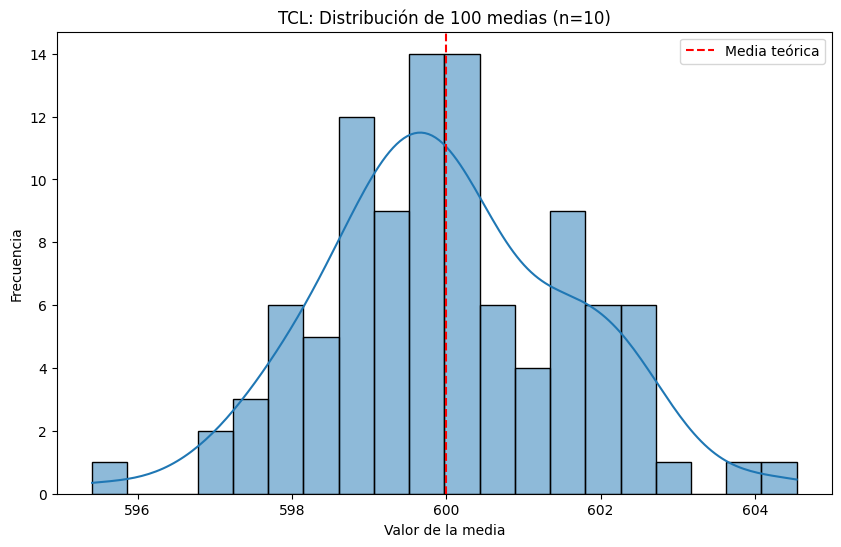

In [45]:
media_teorica = 1000 * 0.6   # n*p
n_muestras = 100            #  100 columnas
tamano_muestra = 10         # Cada columna tiene 10 datos

plt.figure(figsize=(10,6))
# KDE (linea suavizada)
sns.histplot(df_medias,kde=True, color="seagreen", bins=20)
plt.axvline(x=media_teorica, color='red', linestyle='--', label="Media teórica")
plt.title(f"TCL: Distribución de {n_muestras} medias (n={tamano_muestra})")
plt.xlabel("Valor de la media")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()